### **Exploring, cleaning and feature engineering**

Raw scrape in, model-ready tables out. Most amenity columns do not exist in the
source data at all -- they are built here from the ad text, so a large part of
this notebook is turning `title` and `content` into flags.
See `docs/text_extraction_workflow.pdf` for the whole path in one picture.

- **in** -- `real_estate.parquet`, 810,888 rows, 46 columns straight from the scrape
- **out** -- `model_sell_estates.parquet` and `model_rental_estates.parquet`
- **runs on** -- `cudf`, so the frame stays in GPU memory from read to write
- **environment** -- `pip install -e ".[gpu,notebook]"`, not the `!pip install` lines
  that used to sit in this notebook

In [82]:
!nvidia-smi

Mon Aug 10 14:47:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:09:00.0  On |                  N/A |
| 53%   34C    P2            143W /  390W |    6341MiB /  24576MiB |     11%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [85]:
import cudf
import cupy as cp 
import pandas as pd
import numpy as np

In [86]:
pd.set_option("display.max_columns", 200)   
pd.set_option("display.width", 2000)        
pd.set_option("display.max_colwidth", 100)

In [87]:
%%time

data = cudf.read_parquet("../data/real_estate.parquet")
data.head()

CPU times: user 812 ms, sys: 132 ms, total: 944 ms
Wall time: 811 ms


,user_id,id,uri,title,price,content,imgs,refresh,category,beds,livings,wc,area,type,street_width,age,last_update,street_direction,ketchen,ac,furnished,location.lat,location.lng,path,user.review,user.img,user.name,user.phone,user.iam_verified,user.rega_id,native.logo,native.title,native.image,native.description,native.external_url,rent_period,city,city_id,district,district_id,width,length,advertiser_type,create_time,has_extended_details,daily_rentable
0,10065,4331,شارع-الياقوت-الدار-البيضاء-الرياض,"أرض للبيع في شارع الياقوت, الدار البيضاء, الرياض",1958400,تجاريه ش ياقوت ٦٠ مساحه ٨١٦ تقريبا,"[""000000000_1627687178830.jpg""]",1672495809,2,0.0,0.0,0.0,816.0,2.0,60.0,0.0,1672495824,4.0,0.0,0.0,0.0,24.548930,46.781390,/أراضي-للبيع/الرياض/جنوب-الرياض/حي-الدار-البيضاء/شارع-الياقوت-الدار-البيضاء-الرياض,3.83,,ابو زايد,0,1.0,2295425,NaN,NaN,<NA>,NaN,<NA>,0.0,الرياض,21,حي الدار البيضاء,424,25.0,32.0,NaN,1415294130,NaN,0.0
1,11005,4837,طريق-الملك-عبدالله-بن-عبدالعزيز-الفرعي-المغرزات-الرياض,"أرض للبيع في طريق الملك عبدالله بن عبدالعزيز الفرعي, المغرزات, الرياض",15078000,الارض على طريق الملك عبدالله على شارعين مظاهره ٨٠ و ١٥\nالاطوال\n٢٥* ٤٣.١ عمق,"[""000000000_1627687181813.jpg""]",1672040788,2,0.0,0.0,0.0,1077.0,2.0,80.0,0.0,1672040803,4.0,0.0,0.0,0.0,24.754130,46.724820,/أراضي-للبيع/الرياض/شمال-الرياض/حي-المغرزات/طريق-الملك-عبدالله-بن-عبدالعزيز-الفرعي-المغرزات-الرياض,4.56,551515516_1501071840092.jpg,مؤسسة بيت الأثرياء للعقارات,0,1.0,NaN,NaN,NaN,<NA>,NaN,<NA>,0.0,الرياض,21,حي المغرزات,566,NaN,NaN,NaN,1416054461,NaN,0.0
2,8017,5498,5-المملكة-العربية-السعودية-5498,أرض للبيع في 5 المملكة العربية السعودية,8057700,الارض استثماريه في محافظة البرك طريق جده جازان \nجنوب الارض شاليهات البحر مطل ع الارض مباشرة بعد...,"[""506610555_1417214243205.jpg"",""506610555_1417214243875.jpg"",""506610555_1417214244521.jpg""]",1671819056,2,0.0,0.0,0.0,23022.0,3.0,15.0,0.0,1671819056,3.0,0.0,0.0,0.0,18.268720,41.516460,/أراضي-للبيع/محايل/حي-الروضة/5-المملكة-العربية-السعودية-5498,NaN,506610555_1570358699065.jpg,راكان الشاعري,0,1.0,NaN,NaN,NaN,<NA>,NaN,<NA>,0.0,محايل,92,حي الروضة,4100,NaN,NaN,NaN,1417220044,NaN,0.0
3,13810,6520,شارع-Saher-Al-Garbee-St-ذهبان,"أرض للإيجار في شارع الهزاعية, حي العشيرية, جدة",50000,السلام عليكم ورحمة الله وبركاته\nوكل عام وانتم بخير \nاسعد الله اوقاتكم بكل خير\nمساحة الارض 400...,"[""504121665_1418232181483.jpg"",""504121665_1418232181636.jpg"",""504121665_1418232181750.jpg"",""5041...",1672190424,15,0.0,0.0,0.0,400.0,3.0,35.0,0.0,1672190424,4.0,0.0,0.0,0.0,21.892200,39.126540,/أراضي-للإيجار/جدة/شمال-جدة/حي-الرياض/شارع-Saher-Al-Garbee-St-ذهبان,4.43,504121665_1614727198836.jpg,عصام آل جمعان,0,1.0,5907435,NaN,NaN,<NA>,NaN,<NA>,0.0,جدة,66,حي الرياض,3490,20.0,20.0,NaN,1418232587,NaN,0.0
4,5234,8847,طريق-الملك-خالد-حي-الثقبة-الخبر-الخبر-8847,أرض للبيع في طريق الملك خالد ، حي الثقبة ، الخبر ، الخبر,3000000,ارض للبيع لبناء شقق فندقيه او عمارات سكنيه خلف فينيسيا مول قريب الراشد وشارع الملك عبدالله والمل...,"[""567772202_1632148243568.png"",""000052346_1661453484842.jpg""]",1672253180,2,0.0,0.0,0.0,870.0,3.0,15.0,0.0,1672253180,7.0,0.0,0.0,0.0,26.285235,50.180363,/أراضي-للبيع/الخبر/حي-الثقبة/طريق-الملك-خالد-حي-الثقبة-الخبر-الخبر-8847,4.76,1621763009232.jpg,أساس الخليجيه العقاريه 922293,0,1.0,922293,NaN,NaN,<NA>,NaN,<NA>,0.0,الخبر,12,حي الثقبة,1060,NaN,NaN,NaN,1420232812,NaN,0.0


In [88]:
df = data.copy()

### **Exploring Data & Cleaning**

In [89]:
df.info()

<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 810888 entries, 0 to 810887
Data columns (total 46 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   user_id               810888 non-null  int64
 1   id                    810888 non-null  int64
 2   uri                   810888 non-null  str
 3   title                 810715 non-null  str
 4   price                 810888 non-null  int64
 5   content               809026 non-null  str
 6   imgs                  810888 non-null  str
 7   refresh               810888 non-null  int64
 8   category              810888 non-null  int64
 9   beds                  514847 non-null  float64
 10  livings               483251 non-null  float64
 11  wc                    482001 non-null  float64
 12  area                  810306 non-null  float64
 13  type                  264715 non-null  float64
 14  street_width          721638 non-null  float64
 15  age                   530820

In [90]:
info = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.count().to_pandas(),
})
info["null_%"] = (100 - info["non_null"] / len(df) * 100).round(1)
info

,dtype,non_null,null_%
user_id,int64,810888,0.0
id,int64,810888,0.0
uri,str,810888,0.0
title,str,810715,0.0
price,int64,810888,0.0
content,str,809026,0.2
imgs,str,810888,0.0
refresh,int64,810888,0.0
category,int64,810888,0.0
beds,float64,514847,36.5


In [91]:
#Dropping some useless columns

df.drop(columns=['user_id','user.img','native.title','native.image','native.image','native.description','native.external_url'],inplace=True)

In [92]:
df.info()

<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 810888 entries, 0 to 810887
Data columns (total 40 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   id                    810888 non-null  int64
 1   uri                   810888 non-null  str
 2   title                 810715 non-null  str
 3   price                 810888 non-null  int64
 4   content               809026 non-null  str
 5   imgs                  810888 non-null  str
 6   refresh               810888 non-null  int64
 7   category              810888 non-null  int64
 8   beds                  514847 non-null  float64
 9   livings               483251 non-null  float64
 10  wc                    482001 non-null  float64
 11  area                  810306 non-null  float64
 12  type                  264715 non-null  float64
 13  street_width          721638 non-null  float64
 14  age                   530820 non-null  float64
 15  last_update           8108

In [93]:
info = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.count().to_pandas(),
})
info["null_%"] = (100 - info["non_null"] / len(df) * 100).round(1)
info

,dtype,non_null,null_%
id,int64,810888,0.0
uri,str,810888,0.0
title,str,810715,0.0
price,int64,810888,0.0
content,str,809026,0.2
imgs,str,810888,0.0
refresh,int64,810888,0.0
category,int64,810888,0.0
beds,float64,514847,36.5
livings,float64,483251,40.4


In [94]:
df.drop(columns=['native.logo','refresh','user.name','user.phone','user.rega_id','advertiser_type','create_time','has_extended_details'],inplace=True)

In [95]:
df.info()

<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 810888 entries, 0 to 810887
Data columns (total 32 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   id                 810888 non-null  int64
 1   uri                810888 non-null  str
 2   title              810715 non-null  str
 3   price              810888 non-null  int64
 4   content            809026 non-null  str
 5   imgs               810888 non-null  str
 6   category           810888 non-null  int64
 7   beds               514847 non-null  float64
 8   livings            483251 non-null  float64
 9   wc                 482001 non-null  float64
 10  area               810306 non-null  float64
 11  type               264715 non-null  float64
 12  street_width       721638 non-null  float64
 13  age                530820 non-null  float64
 14  last_update        810888 non-null  int64
 15  street_direction   664991 non-null  float64
 16  ketchen            445278 no

In [96]:
df['ac'].value_counts()

ac
1.0    73383
0.0    58537
Name: count, dtype: int64

In [97]:
df[df['ac'] == 1]

,id,uri,title,price,content,imgs,category,beds,livings,wc,area,type,street_width,age,last_update,street_direction,ketchen,ac,furnished,location.lat,location.lng,path,user.review,user.iam_verified,rent_period,city,city_id,district,district_id,width,length,daily_rentable
69,166448,المملكة-العربية-السعودية-166448,شقة للإيجار في المملكة العربية السعودية,13000,عماره جديده شقق عزاب بصناعية المدار علئ طريق الجزاير ،، مكيفه بالكامل مكونه سويتات كل سويت غرف...,"[""555277676_1459875264111.jpg"",""555277676_1472131360827.jpg"",""555277676_1472131362144.jpg"",""5552...",1,1.0,1.0,1.0,40.0,1.0,15.0,0.0,1671805879,2.0,1.0,1.0,0.0,26.240353,50.200110,/شقق-للإيجار/الخبر/حي-ابن-سينا/المملكة-العربية-السعودية-166448,3.28,1.0,3.0,الخبر,12,حي ابن سينا,1038,NaN,NaN,0.0
136,392028,شارع-ابن-الهيثم-الخليج-الرياض-392028,"شقة للإيجار في شارع ابن الهيثم, الخليج, الرياض",250,شقق فندقيه للأيجار اليومي والشهري \nتتكون من غرفه وصاله و غرفتين وصاله \nاضافه الا خدمات الكفي و...,"[""501561119_1547160752513.jpg"",""501561119_1547160752518.jpg"",""501561119_1547160752519.jpg"",""5015...",1,1.0,1.0,1.0,0.0,0.0,0.0,2.0,1672081452,0.0,1.0,1.0,1.0,24.789820,46.814480,/شقق-للإيجار/الرياض/شرق-الرياض/حي-الخليج/شارع-ابن-الهيثم-الخليج-الرياض-392028,3.86,1.0,1.0,الرياض,21,حي الخليج,422,NaN,NaN,0.0
143,409460,الخبر-الجنوبية-الخبر-409460,"شقة للإيجار في الخبر الجنوبية, الخبر",13000,شقق عزاب تشطيب فاااخر\n\nعمارة جديده ،بالخبر الجنوبية خلف الجوازات والدفاع المدني مباشرة بطن \nك...,"[""555277676_1483886015373.jpg"",""555277676_1483886015553.jpg"",""555277676_1504893945025.jpg"",""5552...",1,1.0,1.0,1.0,0.0,3.0,15.0,0.0,1671805871,1.0,1.0,1.0,0.0,26.278220,50.214300,/شقق-للإيجار/الخبر/حي-الخبر-الجنوبية/الخبر-الجنوبية-الخبر-409460,3.28,1.0,3.0,الخبر,12,حي الخبر الجنوبية,1072,NaN,NaN,0.0
145,411267,شارع-ابن-الهيثم-الخليج-الرياض-411267,"شقة للإيجار في شارع ابن الهيثم, الخليج, الرياض",300,شقق فندقيه للأيجار اليومي والشهري \nتتكون من غرفه وصاله و غرفتين وصاله \nاضافه الا خدمات الكفي و...,"[""501561119_1547160639069.jpg"",""501561119_1547160639073.jpg"",""501561119_1547160639074.jpg"",""5015...",1,2.0,1.0,1.0,0.0,0.0,0.0,2.0,1672081454,0.0,1.0,1.0,1.0,24.789640,46.814550,/شقق-للإيجار/الرياض/شرق-الرياض/حي-الخليج/شارع-ابن-الهيثم-الخليج-الرياض-411267,3.86,1.0,1.0,الرياض,21,حي الخليج,422,NaN,NaN,0.0
182,528457,حي-شارع-العاشر-حي-مدينة-العمال-الدمام-الدمام-528457,شقة للإيجار في حي ، شارع العاشر ، حي مدينة العمال ، الدمام ، الدمام,1500,عروض خاصة للمهندسين\nغرف فخمة وسويتات فاخرة بمقاسات ومواصفات مختلفة,"[""548899988_1494357998352.jpg"",""548899988_1494357998894.jpg"",""548899988_1498742447572.jpg"",""5488...",1,2.0,0.0,1.0,0.0,0.0,0.0,0.0,1672571934,0.0,1.0,1.0,1.0,26.426020,50.106325,/شقق-للإيجار/الدمام/حي-مدينة-العمال/حي-شارع-العاشر-حي-مدينة-العمال-الدمام-الدمام-528457,4.5,1.0,2.0,الدمام,18,حي مدينة العمال,1326,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
810861,6583441,شارع-أبراد-حي-التعاون-الرياض-منطقة-الرياض-6583441,دور للإيجار في شارع أبراد ، حي التعاون ، الرياض ، منطقة الرياض,65000,NaN,"[""008437960_1770662028062.jpg"",""008437968_1770662028044.jpg"",""008437969_1770662876921.jpg"",""0084...",4,3.0,2.0,3.0,250.0,NaN,5.0,15.0,1770663005,3.0,NaN,1.0,0.0,24.777672,46.703461,/دور-للإيجار/الرياض/شمال-الرياض/حي-التعاون/شارع-أبراد-حي-التعاون-الرياض-منطقة-الرياض-6583441,5.0,1.0,3.0,الرياض,21,حي التعاون,404,NaN,NaN,0.0
810862,6583444,شارع-عبدالله-ابن-عبد-مناف-حي-العريض-المدينة-المنورة-منطقة-المدينة-المنورة-6583444,شقة للإيجار في شارع عبدالله ابن عبد مناف ، حي العريض ، المدينة المنورة ، منطقة المدينة المنورة,5000,شقة مؤثثه بالكامل \nغرفة جلوس وغرفة نوم وحمام ومطبخ \nالإيجار شهر رمضان فقط,"[""017178082_1770662075520.jpg"",""017178081_1770662075523.jpg"",""017178088_1770662075520.jpg"",""0171...",1,2.0,0.0,1.0,75.0,NaN,5.0,10.0,1770662392,NaN,1.0,1.0,1.0,24.481346,39.647175,/شقق-للإيجار/المدينة-المنورة/حي-العريض/شارع-عبدالله-ابن-عبد-مناف-حي-العريض-المدينة-المنورة-منطقة...,NaN,1.0,3.0,المدينة المنور

In [98]:
df[df['category']==21]

,id,uri,title,price,content,imgs,category,beds,livings,wc,area,type,street_width,age,last_update,street_direction,ketchen,ac,furnished,location.lat,location.lng,path,user.review,user.iam_verified,rent_period,city,city_id,district,district_id,width,length,daily_rentable
97,252945,رحاب-الطائف-252945,"شقة مفروشة في رحاب, الطائف",3000,ايجار يومي ب ٣٠٠ ريال وشهري ب ١٥٠٠ ريال وسنوي والمواسم الشهر ب ٣٠٠٠ ريال\nشباب - عائلات,"[""568822612_1469563121584.jpg"",""568822612_1469563121690.jpg"",""568822612_1469563121944.jpg"",""0020...",21,3.0,1.0,2.0,300.0,0.0,0.0,4.0,1672278660,0.0,1.0,0.0,0.0,21.467590,40.445210,/شقة-مفروشة/الطائف/حي-جبرة/رحاب-الطائف-252945,4.14,1.0,2.0,الطائف,26,حي جبرة,3362,NaN,NaN,0.0
684,1329627,أبها-1329627,شقة مفروشة في أبها,7000,صيفي بالشهر وليس ايام او اسبوع فقط بالشهر \n نوجر \nوالسنوي الدراسي سعر اخر فقط سنه دراسيه ٢\nش...,"[""505795014_1546707283642.jpg"",""505795014_1546707283644.jpg"",""505795014_1546707283645.jpg"",""5057...",21,3.0,2.0,3.0,200.0,NaN,15.0,3.0,1672597936,NaN,1.0,1.0,1.0,18.233078,42.623943,/شقة-مفروشة/ابها/حي-القريقر/أبها-1329627,4.53,1.0,2.0,ابها,1,حي القريقر,3814,12.0,16.0,0.0
703,1347204,شارع-ابن-حديد-حي-الربوة-الرياض-1347204,شقة مفروشة في شارع ابن حديد ، حي الربوة ، الرياض,4500,شقة مفروشة غرفتين وصالة حي الربوة قريبه من حديقة النهضة الإيجار شامل انترنت الياف بصرية الماء ...,"[""544734445_1547565444753.jpg"",""544734445_1547565444978.jpg"",""544734445_1547565444995.jpg"",""5447...",21,2.0,0.0,2.0,NaN,NaN,NaN,0.0,1672132601,NaN,1.0,1.0,1.0,24.679017,46.761154,/شقة-مفروشة/الرياض/وسط-الرياض/حي-الربوة/شارع-ابن-حديد-حي-الربوة-الرياض-1347204,4.15,1.0,2.0,الرياض,21,حي الربوة,438,NaN,NaN,0.0
861,1511347,حي-الواحة-الدمام-الدمام-1511347,شقة مفروشة في حي الواحة ، الدمام ، الدمام,5500,شقه عائلية مؤثثه تشطيب راقي جداً\n\n\n‏يقع العقار في الدمام حي الواحة \nقريب من طريق الجبيل وقري...,"[""509832333_1600422987949.jpg"",""509832333_1600423023810.jpg"",""509832333_1600423470396.jpg"",""5098...",21,2.0,1.0,1.0,85.0,NaN,45.0,3.0,1672416605,5.0,1.0,1.0,1.0,26.379477,50.099312,/شقة-مفروشة/الدمام/حي-النزهة/حي-الواحة-الدمام-الدمام-1511347,4.56,1.0,2.0,الدمام,18,حي النزهة,1300,NaN,NaN,0.0
1044,1682850,شارع-الملك-فيصل-الغربي-الجبيل-1682850,شقة مفروشة في شارع الملك فيصل الغربي ، الجبيل,55000,للمهتمين بالخصوصية العائلية والباحثين عن الهدوء والرفاهية والخدمات يسرنا ان نقدم لكم مجمع سكني ك...,"[""591222180_1565428416887.jpg"",""591222180_1565428416932.jpg"",""591222180_1565428416971.jpg"",""5912...",21,2.0,1.0,2.0,120.0,NaN,30.0,27.0,1671296031,5.0,1.0,1.0,1.0,26.976974,49.648117,/شقة-مفروشة/الجبيل/حي-مخطط-الدخل-المحدود/شارع-الملك-فيصل-الغربي-الجبيل-1682850,4.38,1.0,3.0,الجبيل,8,حي مخطط الدخل المحدود,1022,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662728,5488965,حي-الأندلس-الخبر-الخبر-5488965,شقة مفروشة في حي الأندلس ، الخبر ، الخبر,10500,الشقة مفروشة بالكامل وتقع في الحزام الذهبي ، حيث يتميز الحي بالهدوء ويعتبر من المناطق الأنيقة و...,"[""010979432_1691069152817.jpg"",""010979438_1691069152858.jpg"",""010979431_1691069152844.jpg"",""0109...",21,4.0,1.0,NaN,179.0,NaN,30.0,8.0,1691070675,NaN,NaN,1.0,NaN,26.320988,50.186478,/شقة-مفروشة/الخبر/حي-الاندلس/حي-الأندلس-الخبر-الخبر-5488965,5.0,1.0,2.0,الخبر,12,حي الاندلس,1046,8.0,22.0,NaN
663225,5489544,شارع-أبي-الشيخ-الأصبهاني-حي-المهدية-الرياض-امارة-منطقة-الرياض-5489544,شقة مفروشة في شارع أبي الشيخ الأصبهاني ، حي المهدية ، الرياض ، امارة منطقة الرياض,4500,السلام عليكم\nاعرض لكم شقه مفروشه مؤثثه كامله للايجار الشهري بحي المهديه قريبه جداً من الدائري ق...,"[""000247553_1691092481058.jpg"",""000247559_1691102140324.jpg"",""000247555_1691102140309.jpg"",""0002...",21,4.0,1.0,NaN,200.0,NaN,24.0,NaN,1691153416,NaN,NaN,1.0,NaN,24.662474,46.535660,/شقة-مفروشة/الرياض/غرب-الرياض/حي-المهدية/شارع-أبي-الشيخ-الأصبهاني-حي-المهدية-الرياض-امارة-منطقة-...,4.2,1.0,2.0,الرياض,21,حي المهدية,588,20.0,10.0,NaN
663458,5489833,شارع-خالد-بن-هشام-بن-المغيره-بن-عبد-الله-حي-العزيزية-الثاني-الهفوف‎-الاح

##### **`category` splits into `estate_type` and `estate_benefit`**

One integer encodes both what the property is and whether it is for sale or rent, so it is unusable as a feature until it is split into the two things it actually means.

In [99]:
# Engineer new features [estate_type , estate_ benefit]
CATEGORY_MAP = {
    1: ("apartment", "rental"),   2: ("land", "sell"),
    3: ("villa", "sell"),         4: ("floor", "rental"),
    5: ("villa", "rental"),       6: ("apartment", "sell"),
    7: ("building", "sell"),      8: ("store", "rental"),
    9: ("house", "sell"),        10: ("esterahah", "sell"),
   11: ("house", "rental"),      12: ("farm", "sell"),
   13: ("esterahah", "rental"),  14: ("office", "rental"),
   15: ("land", "rental"),       16: ("building", "rental"),
   17: ("warehouse", "rental"),  18: ("campsite", "rental"),
   19: ("room", "rental"),       20: ("store", "sell"),
   21: ("furnished_apartment", "rental"),
   22: ("floor", "sell"),        23: ("chalet", "rental"),
}

lookup = cudf.DataFrame({
    "category":       list(CATEGORY_MAP.keys()),
    "estate_type":    [v[0] for v in CATEGORY_MAP.values()],
    "estate_benefit": [v[1] for v in CATEGORY_MAP.values()],
})

df = df.merge(lookup, on="category", how="left")

df["estate_type"] = df["estate_type"].astype("category")
df["estate_benefit"] = df["estate_benefit"].astype("category")

In [100]:
df.sample(5)

,id,uri,title,price,content,imgs,category,beds,livings,wc,area,type,street_width,age,last_update,street_direction,ketchen,ac,furnished,location.lat,location.lng,path,user.review,user.iam_verified,rent_period,city,city_id,district,district_id,width,length,daily_rentable,estate_type,estate_benefit
201367,4885518,شارع-أبي-عبد-الله-الموصلي-حي-الصوارى-جدة-جدة-4885518,شقة للبيع في شارع أبي عبد الله الموصلي ، حي الصوارى ، جدة ، جدة,680000,معلن عقاري معتمد من الهيئة العامة للعقار9059986\n شقق للتمليك في ابحر الشمالية مخطط الفال\n\n\nش...,"[""026455280_1671624501595.jpg"",""026455285_1671624511096.jpg"",""026455286_1671624520885.jpg"",""0264...",6,5.0,1.0,3.0,165.0,NaN,27.0,0.0,1671624736,1.0,1.0,NaN,0.0,21.790272,39.095938,/شقق-للبيع/جدة/شمال-جدة/حي-الصوارى/شارع-أبي-عبد-الله-الموصلي-حي-الصوارى-جدة-جدة-4885518,5.00,1.0,NaN,جدة,66,حي الصوارى,3532,165.0,165.0,0.0,apartment,sell
230911,4960714,شارع-عبدالله-بن-شايق-حي-قرطبة-الرياض-الرياض-4960714,شقة للإيجار في شارع عبدالله بن شايق ، حي قرطبة ، الرياض ، الرياض,60000,((تم تأجير جميع الشقق))\nشقق للايجار - قرطبة\nموقع مميز ومساحات كبيرة \nمواقف خاصة مع وجود حارس ...,"[""003688566_1669404927831.jpg"",""003688564_1669404927856.jpg"",""003688565_1669404926962.jpg"",""0036...",1,4.0,1.0,3.0,200.0,NaN,36.0,0.0,1671026656,NaN,1.0,1.0,0.0,24.823446,46.727275,/شقق-للإيجار/الرياض/شرق-الرياض/حي-قرطبة/شارع-عبدالله-بن-شايق-حي-قرطبة-الرياض-الرياض-4960714,5.00,1.0,3.0,الرياض,21,حي قرطبة,706,10.0,20.0,0.0,apartment,rental
290252,5096460,حي-النور-الدمام-الدمام-5096460,شقة للبيع في حي النور ، الدمام ، الدمام,440000,التفاصيل:\nعرض:: \n⭐🌟✳️شقق تمليك فاخره في حي النور⭐🌟✳️\n \n📞📞 📞📞\n\nتف...,"[""026981270_1674135940325.jpg"",""026981273_1674135940460.jpg"",""026981279_1674135940159.jpg"",""0269...",6,4.0,1.0,3.0,150.0,NaN,40.0,0.0,1675322221,2.0,1.0,NaN,0.0,26.439421,50.031357,/شقق-للبيع/الدمام/حي-النور/حي-النور-الدمام-الدمام-5096460,5.00,1.0,NaN,الدمام,18,حي النور,1306,10.0,15.0,NaN,apartment,sell
276777,5067818,شارع-سعيد-البصري-حي-المروة-جدة-جدة-5067818,شقة للبيع في شارع سعيد البصري ، حي المروة ، جدة ، جدة,800000,شقق تمليك للبيع بجده حي المروة\nأفراغ فوري نورفر الدفعه الاول\nنقبل الفايض\nالبيع بنك او كاش\nحي...,"[""008773354_1673170246543.jpg"",""008773359_1673170246582.jpg"",""008773357_1673170246537.jpg"",""0087...",6,7.0,1.0,4.0,250.0,NaN,16.0,0.0,1673713066,3.0,1.0,NaN,0.0,21.609810,39.214642,/شقق-للبيع/جدة/شمال-جدة/حي-المروة/شارع-سعيد-البصري-حي-المروة-جدة-جدة-5067818,4.42,1.0,NaN,جدة,66,حي المروة,3586,12.0,20.0,0.0,apartment,sell
488657,5276890,شارع-الجنادل-حي-الازدهار-الرياض-الرياض-5276890,فيلا للبيع في شارع الجنادل ، حي الازدهار ، الرياض ، الرياض,2500000,*للبيع فله صاله درج في حي الازدهار المربع الذهبي*\n*الموقع* / قريب جداً من الدائري الشمالي والشر...,"[""029396172_1680499929244.jpg"",""029396176_1680499928911.jpg"",""029396178_1680499929246.jpg"",""0293...",3,3.0,2.0,3.0,312.0,NaN,15.0,20.0,1683015085,1.0,1.0,NaN,0.0,24.789875,46.717156,/فلل-للبيع/الرياض/شرق-الرياض/حي-الازدهار/شارع-الجنادل-حي-الازدهار-الرياض-الرياض-5276890,4.36,1.0,NaN,الرياض,21,حي الازدهار,392,20.0,16.0,NaN,villa,sell


In [101]:
df[(df['estate_type'] == 'apartment')&(df['estate_benefit']=='rental')]

,id,uri,title,price,content,imgs,category,beds,livings,wc,area,type,street_width,age,last_update,street_direction,ketchen,ac,furnished,location.lat,location.lng,path,user.review,user.iam_verified,rent_period,city,city_id,district,district_id,width,length,daily_rentable,estate_type,estate_benefit
70,4497101,طريق-الأمير-نايف-بن-عبدالعزيز-حي-غرناطة-الدمام-الدمام-4497101,شقة للإيجار في طريق الأمير نايف بن عبدالعزيز ، حي غرناطة ، الدمام ، الدمام,1900,شقة عوائل نظيفة ومؤثثه غرفه وصاله ودوره مياه شامل الماء والكهرباء والنت والغاز والصيانة الطارئة....,"[""003259642_1656960158778.jpg"",""003259645_1656960158770.jpg"",""003259642_1656960158797.jpg""]",1,1.0,1.0,1.0,160.0,NaN,25.0,NaN,1672157290,NaN,1.0,1.0,1.0,26.425081,50.071888,/شقق-للإيجار/الدمام/حي-غرناطة/طريق-الأمير-نايف-بن-عبدالعزيز-حي-غرناطة-الدمام-الدمام-4497101,4.48,1.0,2.0,الدمام,18,حي غرناطة,1322,30.0,5.0,0.0,apartment,rental
74,4497118,طريق-الأمير-نايف-بن-عبدالعزيز-حي-غرناطة-الدمام-الدمام-4497118,شقة للإيجار في طريق الأمير نايف بن عبدالعزيز ، حي غرناطة ، الدمام ، الدمام,2500,شقة عوائل نظيفة غرفتين وصاله ودوره مياه ومطبخ شامل الكهرباء والماء والنت والغاز .\n\nجوال واتساب...,"[""003259643_1656960449443.jpg"",""003259647_1656960449412.jpg"",""003259648_1656960449394.jpg"",""0032...",1,2.0,1.0,1.0,190.0,NaN,5.0,NaN,1672157294,NaN,1.0,1.0,1.0,26.425016,50.071762,/شقق-للإيجار/الدمام/حي-غرناطة/طريق-الأمير-نايف-بن-عبدالعزيز-حي-غرناطة-الدمام-الدمام-4497118,4.48,1.0,2.0,الدمام,18,حي غرناطة,1322,50.0,3.0,0.0,apartment,rental
144,4642907,شارع-الحيسية-حي-اشبيلية-الرياض-الرياض-4642907,شقة للإيجار في شارع الحيسية ، حي اشبيلية ، الرياض ، الرياض,4000,شقه عوائل مفروشه شهري في فيلا بحي اشبيليا الرياض\nالشقه جديده وموقعها جدا حلو وجميع الخدمات قريب...,"[""002287292_1660680421399.jpg"",""002287298_1660680421400.jpg"",""002287292_1660680421391.jpg"",""0022...",1,2.0,2.0,2.0,150.0,NaN,5.0,NaN,1671548687,NaN,1.0,1.0,1.0,24.787817,46.781475,/شقق-للإيجار/الرياض/شرق-الرياض/حي-اشبيلية/شارع-الحيسية-حي-اشبيلية-الرياض-الرياض-4642907,3.81,1.0,2.0,الرياض,21,حي اشبيلية,390,10.0,15.0,0.0,apartment,rental
168,4643182,حي-الضرس-محايل-عسير-محايل-4643182,شقة للإيجار في حي الضرس ، محايل عسير ، محايل,1500,عدد غرف النوم 2\nعدد مجالس 2\nعدد حمام 3\nخزان موية مستقل كهربائي مستقل \nصاله 1,"[""022586886_1660683877045.jpg"",""022586884_1660683877060.jpg"",""022586885_1660683877043.jpg"",""0225...",1,4.0,1.0,3.0,225.0,NaN,5.0,3.0,1672318788,NaN,1.0,1.0,0.0,18.539719,42.087017,/شقق-للإيجار/محايل/حي-الضرس/حي-الضرس-محايل-عسير-محايل-4643182,NaN,1.0,2.0,محايل,92,حي الضرس,4108,15.0,15.0,0.0,apartment,rental
182,4643422,طريق-الملك-عبرالعزيز-حي-العزيزية-حوطة-سدير-المجمعة-4643422,شقة للإيجار في طريق الملك عبرالعزيز ، حي العزيزية ، حوطة سدير ، المجمعة,1750,للايجار شقق نسائية 100%\n\nمؤثث بالكامل مع الخدمات\n\nفي حوطة سدير \n\nقريب من الخدمات \n\nدفع ش...,"[""012178025_1660690307893.jpg""]",1,2.0,1.0,1.0,200.0,NaN,40.0,0.0,1672524396,NaN,1.0,1.0,1.0,25.597826,45.610302,/شقق-للإيجار/المجمعة/حي-الملك-عبدالله/طريق-الملك-عبرالعزيز-حي-العزيزية-حوطة-سدير-المجمعة-4643422,5.0,1.0,2.0,المجمعة,40,حي الملك عبدالله,870,100.0,2.0,0.0,apartment,rental
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
810873,6578089,شارع-قنا-والبحر-حي-النزهة-مدينة-جدة-منطقة-مكة-المكرمة-6578089,"شقة للإيجار في شارع قنا والبحر, حي النزهة, مدينة جدة, منطقة مكة المكرمة",24000,ملحق علوي مفروش للإيجار – حي النزهة (جدة)\n📍 الموقع: جدة – حي النزهة\n\n📜 الوصف العقاري:\nملحق ع...,"[""002033288_1770314710396.jpg""]",1,2.0,NaN,NaN,750.0,1.0,NaN,1.0,1770634579,NaN,NaN,NaN,NaN,21.622803,39.167812,/شقق-للإيجار/جدة/شمال-جدة/حي-النزهة/شارع-قنا-والبحر-حي-النزهة-مدينة-جدة-منطقة-مكة-المكرمة-6578089,4.0,1.0,3.0,جدة,66,حي النزهة,3602,NaN,NaN,0.0,apartment,rental
810879,6578095,شارع-محمد-بن-عبدالعزيز-الدغيثر-حي-الملقا-مدينة-الرياض-منطقة-الرياض-6578095,"شقة للإيجار في شارع محمد بن عبدالعزيز الدغيثر, حي الملقا, مدينة الرياض, منطقة الرياض",5500,شقه للإيجار بحي الملقا مؤثثة اثاث فاخر ( عوائل ) \nفترة شه

##### **filling `ac` from the ad text**

Only rental types get this: for a sale listing the seller leaving `ac` empty says nothing, but a rental ad that never mentions cooling in a country this hot is a listing without it.

In [102]:
# impute AC column
TARGETS = ["apartment", "chalet", "furnished_apartment", "esterahah", "house", "floor"]

is_target = df["estate_type"].isin(TARGETS) & (df["estate_benefit"] == "rental")
to_fill = is_target & df["ac"].isna()


text = df["title"].fillna("") + " " + df["content"].fillna("")
has_ac = text.str.contains("مكيف|تكييف")

df.loc[to_fill & has_ac, "ac"] = 1.0
df.loc[to_fill & ~has_ac, "ac"] = 0.0

In [103]:
df.loc[to_fill].shape[0]          # how many rows you are about to fill
has_ac[to_fill].sum()             # how many got 1

np.int64(3403)

In [104]:
df['ac'].value_counts()

ac
1.0    76786
0.0    68433
Name: count, dtype: int64

In [105]:
df[df['ac'] == 0]

,id,uri,title,price,content,imgs,category,beds,livings,wc,area,type,street_width,age,last_update,street_direction,ketchen,ac,furnished,location.lat,location.lng,path,user.review,user.iam_verified,rent_period,city,city_id,district,district_id,width,length,daily_rentable,estate_type,estate_benefit
80,4497420,طريق-الملك-سلمان-بن-عبدالعزيز-حي-الاندلس-الخرج-الخرج-4497420,فيلا للإيجار في طريق الملك سلمان بن عبدالعزيز ، حي الاندلس ، الخرج ، الخرج,350000,فلتين تقع في حي الأندلس تطل على طريق الملك سلمان ، عبارة عن بلك كامل 4 شوارع .\nمجموع الغرف (22)...,null,5,7.0,4.0,5.0,2184.0,NaN,40.0,30.0,1672470948,10.0,1.0,0.0,0.0,24.150256,47.340222,/فلل-للإيجار/الخرج/حي-الاندلس/طريق-الملك-سلمان-بن-عبدالعزيز-حي-الاندلس-الخرج-الخرج-4497420,4.0,1.0,NaN,الخرج,13,حي الاندلس,248,42.0,52.0,0.0,villa,rental
111,2999256,حي-المناخ-الرياض-الرياض-2999256,استراحة للإيجار في حي المناخ ، الرياض ، الرياض,13000,سكن عمال 2غرفه+حمام+مطبخ+حوش\nايجار سنوي 13000ريال\nالتواصل واتساب 0557797772,null,13,2.0,0.0,1.0,150.0,NaN,NaN,NaN,1672241488,NaN,1.0,0.0,NaN,24.627315,46.802731,/استراحة-للإيجار/الرياض/جنوب-الرياض/حي-المناخ/حي-المناخ-الرياض-الرياض-2999256,3.71,NaN,3.0,الرياض,21,حي المناخ,580,NaN,NaN,NaN,esterahah,rental
207,4681915,شارع-رشيد-الكيلاني-حي-الرمال-الرياض-الرياض-4681915,شاليه للإيجار في شارع رشيد الكيلاني ، حي الرمال ، الرياض ، الرياض,800,-:يتكون هذا الشاليه المخصص للعوائل والعزاب من \nمجلس رئيسي يتسع لـ 19 شخص \nوجلسة خارجية تتسع لـ...,"[""027416989_1661632497756.jpg"",""027416982_1661632497746.jpg"",""027416986_1661632497750.jpg"",""0274...",23,1.0,1.0,2.0,700.0,NaN,40.0,0.0,1666547878,NaN,1.0,0.0,NaN,24.872753,46.821171,/شاليه-للإيجار/الرياض/شرق-الرياض/حي-الرمال/شارع-رشيد-الكيلاني-حي-الرمال-الرياض-الرياض-4681915,NaN,1.0,1.0,الرياض,21,حي الرمال,446,30.0,23.0,0.0,chalet,rental
259,4151051,محافظة-المزاحمية-المزاحمية-4151051,استراحة للإيجار في محافظة المزاحمية ، المزاحمية,1500,استراحة قسمين راقية مكتملة ومؤثثة بالكامل مع اختلاف السعر أوقات الأعياد ومن الممكن قسم واحد ال...,"[""505209578_1647689640972.jpg"",""505209578_1647689641270.jpg"",""505209578_1647689641381.jpg"",""5052...",13,5.0,1.0,5.0,5000.0,NaN,NaN,NaN,1671315485,NaN,1.0,0.0,NaN,24.460517,46.252752,/استراحة-للإيجار/المزاحمية/حي-غرناطة/محافظة-المزاحمية-المزاحمية-4151051,3.7,0.0,1.0,المزاحمية,43,حي غرناطة,896,NaN,NaN,0.0,esterahah,rental
304,4188013,حي-الأمواج-الخبر-الخبر-4188013,فيلا للإيجار في حي الأمواج ، الخبر ، الخبر,55000,فيلا دوبلكس للايجار في العزيزية الامواج مساحة 500 م على شارع 40 شمال جديده الايجار 55 الف دفعتين...,"[""015988474_1667357220303.jpg"",""015988476_1667357220318.jpg""]",5,7.0,2.0,5.0,500.0,NaN,40.0,0.0,1668700714,1.0,1.0,0.0,0.0,26.139179,50.147060,/فلل-للإيجار/الخبر/حي-الامواج/حي-الأمواج-الخبر-الخبر-4188013,5.0,1.0,NaN,الخبر,12,حي الامواج,1044,NaN,NaN,0.0,villa,rental
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
810873,6578089,شارع-قنا-والبحر-حي-النزهة-مدينة-جدة-منطقة-مكة-المكرمة-6578089,"شقة للإيجار في شارع قنا والبحر, حي النزهة, مدينة جدة, منطقة مكة المكرمة",24000,ملحق علوي مفروش للإيجار – حي النزهة (جدة)\n📍 الموقع: جدة – حي النزهة\n\n📜 الوصف العقاري:\nملحق ع...,"[""002033288_1770314710396.jpg""]",1,2.0,NaN,NaN,750.0,1.0,NaN,1.0,1770634579,NaN,NaN,0.0,NaN,21.622803,39.167812,/شقق-للإيجار/جدة/شمال-جدة/حي-النزهة/شارع-قنا-والبحر-حي-النزهة-مدينة-جدة-منطقة-مكة-المكرمة-6578089,4.0,1.0,3.0,جدة,66,حي النزهة,3602,NaN,NaN,0.0,apartment,rental
810879,6578095,شارع-محمد-بن-عبدالعزيز-الدغيثر-حي-الملقا-مدينة-الرياض-منطقة-الرياض-6578095,"شقة للإيجار في شارع محمد بن عبدالعزيز الدغيثر, حي الملقا, مدينة الرياض, منطقة الرياض",5500,شقه للإيجار بحي الملقا مؤثثة اثاث فاخر ( عوائل ) \nفترة شهر رمضان \nتتكون من : \nمجلس + غرفتين...,"[""049522424_1770315351143.jpg"",""049522424_1770315369865.jpg"",""049522422_1770315452381.jpg"",""0495...",1,3.0,NaN,NaN,114.0,1.0,NaN,7.0,1770638541,NaN,NaN,0.0,NaN,24.796498,46.614571,/شقق-للإيجار/الرياض/شمال-الرياض/حي-الملقا/شارع-محمد-بن-عبدالعزيز-الدغيثر-حي-الملقا-مدينة-ا

In [106]:
df['livings'].unique()

0    1.0
1    NaN
2    5.0
3    0.0
4    2.0
5    3.0
6    4.0
7    7.0
8    6.0
Name: livings, dtype: float64

In [107]:
df['livings'].value_counts()

livings
1.0    236015
2.0    122567
3.0     69774
0.0     30731
4.0     12953
5.0     10999
6.0       134
7.0        78
Name: count, dtype: int64

##### **shape of the text**

Length, emoji count, phone and URL presence -- used to see what the ad bodies look like before writing patterns against them. All of it is dropped again further down; none of it reaches a model.

In [109]:
raw = df["content"].fillna("")
df["len_chars"]   = raw.str.len().astype("int32")
df["len_words"]   = raw.str.count(" ").astype("int16")
df["n_emoji"]     = raw.str.count(r"[\U0001F000-\U0001FAFF\u2600-\u27BF]").astype("int16")
df["n_newlines"]  = raw.str.count("\n").astype("int16")
df["has_phone"]   = raw.str.contains(r"(?:05|٠٥|\+9665)\d{6,}").astype("int8")
df["has_url"]     = raw.str.contains(r"http|www\.|wa\.me|t\.me|snapchat|instagram").astype("int8")
df["has_latin"]   = raw.str.contains(r"[A-Za-z]{3,}").astype("int8")
df["caps_symbols"]= raw.str.count(r"[★☆✅✔️❤🔥●•▪]").astype("int16")

##### **normalising the Arabic**

The same feature is written a dozen ways across 810k free-text ads, so every pattern below would need a dozen spellings without this step:

- emoji, invisible RTL marks and tatweel become spaces, never nothing, so words are not glued together
- diacritics dropped; alef, ya, ta-marbuta and hamza variants unified
- a letter repeated three or more times is collapsed, which is how enthusiastic sellers write
- `title` and `content` are joined first: the headline often carries the one detail the body omits

In [110]:
def normalize_ar(s):
    s = s.fillna("")
    # symbols & emojis → space (not deleted, to avoid gluing words)
    s = s.str.replace(r"[\U0001F000-\U0001FAFF\u2600-\u27BF\u2B00-\u2BFF\uFE0F\u200d]", " ", regex=True)
    s = s.str.replace(r"[\u200b-\u200f\u202a-\u202e]", " ", regex=True)   # invisible RTL marks
    s = s.str.replace("ـ", "", regex=False)                               # tatweel
    s = s.str.replace(r"[\u064B-\u0652\u0670]", "", regex=True)           # diacritics
    s = s.str.replace(r"[إأآٱ]", "ا", regex=True)
    s = s.str.replace("ى", "ي", regex=False)
    s = s.str.replace("ة", "ه", regex=False)
    s = s.str.replace("ؤ", "و", regex=False).str.replace("ئ", "ي", regex=False)
    s = s.str.replace(r"(.)\1{2,}", r"\1", regex=True)                    # جميييييل → جميل
    s = s.str.replace(r"[^\w\s\u0621-\u064A]", " ", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

df["text_norm"] = normalize_ar(df["title"] + " " + df["content"])

In [111]:
for ar, en in zip("٠١٢٣٤٥٦٧٨٩", "0123456789"):
    df["text_norm"] = df["text_norm"].str.replace(ar, en, regex=False)

##### **negations are cut out before anything is matched**

"no pool" contains "pool". Deleting the negation and the words it governs means a denied feature can never be matched as if it were present, which a plain keyword search would get exactly backwards.

In [112]:
NEG = r"(?:لا يوجد|لايوجد|بدون|غير|ما فيه|مافيه|ليس فيه|عدا|ما عدا)\s+\S+\s*\S*"
df["text_pos"] = df["text_norm"].str.replace(NEG, " ", regex=True)

##### **keyword flags**

One `int8` column per pattern, matched against the negation-stripped text.

In [113]:
FEATURES = {
    "f_ac":         r"مكيف|تكييف|سبلت|سبليت|اسبلت|شباك|مركزي|كونسيلد",
    "f_ac_central": r"تكييف مركزي|مكيفات مركزيه|مركزي راكب",
    "f_elevator":   r"مصعد|اسانسير|مصاعد|ليفت",
    "f_parking":    r"موقف|مواقف|كراج|قراج|جراج|باركن|مظله سياره",
    "f_furnished":  r"مفروش|مفروشه|بالاثاث|مع الاثاث|فرش كامل|مؤثث",
    "f_new":        r"جديد|جديده|لم تسكن|لم يسكن|اول ساكن|نظيف جدا|تحت الانشاء",
    "f_pool":       r"مسبح|بركه سباحه|حوض سباحه",
    "f_kitchen":    r"مطبخ راكب|مطبخ مركب|بالمطبخ|مع المطبخ",
    "f_maid":       r"غرفه خادمه|غرفه شغاله|ملحق خادمه",
    "f_driver":     r"غرفه سائق|ملحق سائق",
    "f_roof":       r"سطح|روف|ملحق علوي",
    "f_basement":   r"قبو|بدروم",
    "f_garden":     r"حديقه|حوش|فناء",
    "f_two_entr":   r"مدخلين|مدخل خاص|مدخل مستقل",
    "f_corner":     r"زاويه|ركنيه|شارعين|ثلاث شوارع",
    "f_near_masjid":r"قريب من المسجد|بجوار المسجد|امام المسجد|جامع",
    "f_investment": r"استثمار|دخل شهري|عائد|مؤجر بالكامل",
    "f_negotiable": r"قابل للتفاوض|التفاوض|السوم|قابل للنقاش",
    "f_urgent":     r"للبيع السريع|بيع سريع|مستعجل|بسعر مغري|فرصه",
}

for col, pat in FEATURES.items():
    df[col] = df["text_pos"].str.contains(pat).astype("int8")

In [114]:
rates = df[[c for c in df.columns if c.startswith("f_")]].mean().to_pandas().sort_values()
print((rates * 100).round(2))

f_driver          0.00
f_ac_central      1.08
f_furnished       1.60
f_basement        1.84
f_urgent          3.21
f_near_masjid     3.36
f_pool            3.76
f_investment      4.05
f_kitchen         5.32
f_two_entr       10.35
f_corner         10.39
f_new            11.91
f_maid           12.32
f_negotiable     12.33
f_elevator       12.78
f_parking        13.68
f_ac             14.36
f_garden         18.02
f_roof           20.71
dtype: float64


In [115]:
df["f_driver"] = df["text_pos"].str.contains(r"سائق|سواق").astype("int8")

In [116]:
df["text_norm"].str.contains("سائق").mean() * 100

np.float64(0.0)

In [117]:
df["text_norm"].str.contains("مفروش").mean() * 100

np.float64(1.3921774647053602)

In [118]:
df["ac"].mean()   # among non-null rows, how many are 1?

np.float64(0.528760010742396)

In [119]:
df[df["f_garden"]==1]["content"].head(5).to_pandas().tolist()

['رقم معلن 8108917\nيوجد  لدينا شقق تحت الإنشاء غلى خط المدينه خلف محكمه التنفيذ شارع قريش\nالشقق تتكون  من 5----4\nتتكون الشقه من ٤غرف \nصاله \n٤ دورات مياه \nغرفه خادمه\nموقف خاص \nعداد مستقل خزان مستقله \nمساحه 4 الغرف 151م\nنظام شقتين في الدور \nفي للدور 3 شقق\n\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"مميزات الموقع \\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\nعلى خط المدينه \nخلف محكمة التنفيذ مباشر\nبجوار حديقه \nومسجد \nقريب من مول العرب 5 دقائق\nقريب من شارع حراء \nسهل الدخول والخروج الموقع \n\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"الضمانات \\\\\\\\\\\\\\\'\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\\\\\\\\\\\\\\"\nضمانات على هيكل البناء20سنه

##### **near a park is not the same as having a garden**

The park wording is matched first and then removed, so `f_garden` and `f_yard` see only what is left. Without that, every listing advertising the park across the street claims a garden of its own.

In [120]:
NEAR = r"(?:جوار|بجوار|قريب من|امام|مقابل|بجانب|قرب)\s+\S*\s*(?:حديق|منتزه|بارك)\S*"
df["f_near_park"] = df["text_pos"].str.contains(NEAR).astype("int8")

txt = df["text_pos"].str.replace(NEAR, " ", regex=True)

df["f_garden"] = txt.str.contains(r"حديقه|حديقة|لاند سكيب|مسطح اخضر|زرع").astype("int8")
df["f_yard"]   = txt.str.contains(r"حوش|فناء|ساحه خلفيه").astype("int8")

df[df["f_roof"]==1]["content"].head(5).to_pandas().tolist()

['فلل فاخرة للبيع على الطراز الكلاسيكي\nالموقع خميس مشيط حي الموسى\nمساحة الأرض ٣١٢ م٢\nإجمالي مساحة البناء ٥٥٠ م٢\nالواجهة غربية على شارع عرض ٣٠ م\nالفيلا مكونة من دورين وملحق وغرفة سائق :\nالدور الأرضي : ضيافة مكون من مجلس رجال - صالة طعام - مجلس نساء - صالة وبوفيه ودورات مياه ضيافة ومصعد\nالدور الأول : جناح نوم رئيسي بغرفة ملابس - جناحين نوم بدورتين مياه - مطبخ رئيسي - صالة جلوس\nالملحق : جناحين نوم بدورتين مياه - صالة - غرفة خادمة وغسيل - سطح\nالحوش : حديقة داخلية و مدخل سيارة و نافورة مع أحواض زراعية',
 'ملحق للبيع في مخطط سندس حي الواحة \n٦ غرف بمدخلين \nو صاله ومطبخ\n وغرفة سائق\n  ٤حمامات \nوموقف خاص\n وخزان مستقل علوي وسفلي\n المساحة ١٧٠ متر مباني و ٧٠ متر السطح \nالسعر ٩٧٠  ألف على شارع و ٩٨٠ على شارع وممر',
 '🌟شقة تمليك فاخرة للبيع🌟\nمكونه من*5 غرف*مجلس *ومقلط *وثلاث غرف نوم *وحدة منها ماستر *ومطبخ *وغرفة غسيل*\n\n*خزان مستقل وعداد كهرب خاص*\n*الملاحق مستقله مع سطح خاص*\n*الارضي مدخل خاص مع حوش جانبي*\n\nللاستفسار والمعاينة التواصل اتصال او واتس لسرعة الرد..\n 0506428616\n\n

In [121]:
df.columns

Index(['id', 'uri', 'title', 'price', 'content', 'imgs', 'category', 'beds', 'livings', 'wc', 'area', 'type', 'street_width', 'age', 'last_update', 'street_direction', 'ketchen', 'ac', 'furnished', 'location.lat', 'location.lng', 'path', 'user.review', 'user.iam_verified', 'rent_period', 'city', 'city_id', 'district', 'district_id', 'width', 'length', 'daily_rentable', 'estate_type', 'estate_benefit', 'len_chars', 'len_words', 'n_emoji', 'n_newlines', 'has_phone', 'has_url', 'has_latin', 'caps_symbols', 'text_norm', 'text_pos', 'f_ac', 'f_ac_central', 'f_elevator', 'f_parking', 'f_furnished', 'f_new', 'f_pool', 'f_kitchen', 'f_maid', 'f_driver', 'f_roof', 'f_basement', 'f_garden', 'f_two_entr', 'f_corner', 'f_near_masjid', 'f_investment', 'f_negotiable', 'f_urgent', 'f_near_park', 'f_yard'], dtype='str')

In [122]:
df.sample()

,id,uri,title,price,content,imgs,category,beds,livings,wc,area,type,street_width,age,last_update,street_direction,ketchen,ac,furnished,location.lat,location.lng,path,user.review,user.iam_verified,rent_period,city,city_id,district,district_id,width,length,daily_rentable,estate_type,estate_benefit,len_chars,len_words,n_emoji,n_newlines,has_phone,has_url,has_latin,caps_symbols,text_norm,text_pos,f_ac,f_ac_central,f_elevator,f_parking,f_furnished,f_new,f_pool,f_kitchen,f_maid,f_driver,f_roof,f_basement,f_garden,f_two_entr,f_corner,f_near_masjid,f_investment,f_negotiable,f_urgent,f_near_park,f_yard
591918,5385309,شارع-إبراهيم-بن-علي-السقا-حي-الاندلس-الرياض-امارة-منطقة-الرياض-5385309,فيلا للبيع في شارع إبراهيم بن علي السقا ، حي الاندلس ، الرياض ، امارة منطقة الرياض,3300000,فيلا جديدة مكونه الدور الارضي صالة كبيرة ومجلس ومقلط ومطبخ 2 حمام ومشب ومصعد جاهز للتركيب وحمام ...,"[""004819010_1684938335933.jpg"",""004819019_1684938335939.jpg"",""004819017_1684938336045.jpg"",""0048...",3,7.0,2.0,5.0,375.0,NaN,15.0,0.0,1685142194,4.0,1.0,NaN,0.0,24.735558,46.784939,/فلل-للبيع/الرياض/شرق-الرياض/حي-الاندلس/شارع-إبراهيم-بن-علي-السقا-حي-الاندلس-الرياض-امارة-منطقة-...,4.8,1.0,NaN,الرياض,21,حي الاندلس,396,15.0,25.0,NaN,villa,sell,358,57,36,10,1,0,0,0,فيلا للبيع في شارع ابراهيم بن علي السقا حي الاندلس الرياض اماره منطقه الرياض فيلا جديده مكونه ال...,فيلا للبيع في شارع ابراهيم بن علي السقا حي الاندلس الرياض اماره منطقه الرياض فيلا جديده مكونه ال...,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [123]:
df.drop(columns=['len_chars','len_words','n_emoji','n_newlines','has_phone','has_url','has_latin','caps_symbols','text_norm','text_pos'],inplace=True)

In [124]:
df.sample(5)

,id,uri,title,price,content,imgs,category,beds,livings,wc,area,type,street_width,age,last_update,street_direction,ketchen,ac,furnished,location.lat,location.lng,path,user.review,user.iam_verified,rent_period,city,city_id,district,district_id,width,length,daily_rentable,estate_type,estate_benefit,f_ac,f_ac_central,f_elevator,f_parking,f_furnished,f_new,f_pool,f_kitchen,f_maid,f_driver,f_roof,f_basement,f_garden,f_two_entr,f_corner,f_near_masjid,f_investment,f_negotiable,f_urgent,f_near_park,f_yard
643417,5421480,شارع-سفيان-بن-عوف-حي-العزيزية-الرياض-امارة-منطقة-الرياض-5421480,دور للبيع في شارع سفيان بن عوف ، حي العزيزية ، الرياض ، امارة منطقة الرياض,670000,نوع العقار : دور بصك \nجميع الاوراق جاهزة \n\nالمساحة : 256 متر \n\n\nالواجهة : شرقيه \n\nالحي...,"[""032608489_1686140124701.jpg"",""032608481_1686140124548.jpg"",""032608487_1686140125218.jpg"",""0326...",22,3.0,1.0,3.0,256.0,NaN,20.0,0.0,1688463335,3.0,NaN,NaN,NaN,24.583013,46.771985,/دور-للبيع/الرياض/جنوب-الرياض/حي-العزيزية/شارع-سفيان-بن-عوف-حي-العزيزية-الرياض-امارة-منطقة-الريا...,5.0,1.0,NaN,الرياض,21,حي العزيزية,502,20.0,13.0,0.0,floor,sell,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
787903,6543900,شارع-مثلث-مدينة-المثلث-بالحريضه-منطقة-عسير-6543900,"دور للبيع في شارع مثلث, مدينة المثلث بالحريضه, منطقة عسير",700000,🔶نقدم لكم دور ارضي مشطب تشيط فاخر\n🔶الموقع- الحريضه -مثلث الحريضه \n🔶\n️تمتاز بالتشطيب الفاخر\n...,"[""046673605_1768237062320.jpg"",""046673602_1768237062293.jpg"",""046673603_1768237062294.jpg"",""0466...",22,7.0,NaN,NaN,630.0,1.0,NaN,1.0,1770634451,NaN,NaN,NaN,NaN,17.770575,41.927683,/دور-للبيع/ابها/حي-السروات/شارع-مثلث-مدينة-المثلث-بالحريضه-منطقة-عسير-6543900,NaN,1.0,NaN,ابها,1,حي السروات,3796,NaN,NaN,0.0,floor,sell,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
163274,4753114,شارع-رقم-209-حي-الملقا-الرياض-الرياض-4753114,أرض للبيع في شارع رقم 209 ، حي الملقا ، الرياض ، الرياض,4200000,ملقا نجد \n\n600م \nالسوم 6800\nالبيع 7000 على شور \nاطوالها20*30 \nقطعه رقم \nشارع 18 جنوبي,"[""000000000_1663418932066.jpg""]",2,NaN,NaN,NaN,600.0,NaN,18.0,NaN,1670524492,4.0,NaN,NaN,NaN,24.799358,46.592400,/أراضي-للبيع/الرياض/شمال-الرياض/حي-الملقا/شارع-رقم-209-حي-الملقا-الرياض-الرياض-4753114,3.66,1.0,NaN,الرياض,21,حي الملقا,570,20.0,30.0,0.0,land,sell,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
38682,4264896,شارع-الحديبية-حي-طويق-الرياض-الرياض-4264896,فيلا للبيع في شارع الحديبية ، حي طويق ، الرياض ، الرياض,1020000,السلام عليكم ورحمه الله وبركاته\nتعلن شركة مساكن الصفوه عن بيع فيلا دوبلكس مساحة 200متر واجهة جن...,"[""019825490_1671893718285.jpg"",""019825499_1671893718408.jpg"",""019825499_1671893718663.jpg"",""0198...",3,5.0,1.0,5.0,200.0,NaN,20.0,0.0,1672542862,4.0,1.0,NaN,0.0,24.588565,46.546786,/فلل-للبيع/الرياض/غرب-الرياض/حي-طويق/شارع-الحديبية-حي-طويق-الرياض-الرياض-4264896,4.5,1.0,NaN,الرياض,21,حي طويق,682,10.0,20.0,0.0,villa,sell,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1
509755,5341781,شارع-محمد-علي-جناح-حي-اليرموك-الرياض-الرياض-5341781,أرض للبيع في شارع محمد علي جناح ، حي اليرموك ، الرياض ، الرياض,2437500,*للبيع فله بقيمه ارض بحى اليرموك الغربي \n*مساحه 650م \n*الاطوال 25*26م\n*جنوبيه شارع 20م\n*البي...,"[""000000000_1683482924690.jpg""]",2,NaN,NaN,NaN,650.0,1.0,20.0,NaN,1685733033,4.0,NaN,NaN,NaN,24.799554,46.764492,/أراضي-للبيع/الرياض/شرق-الرياض/حي-اليرموك/شارع-محمد-علي-جناح-حي-اليرموك-الرياض-الرياض-5341781,4.25,1.0,NaN,الرياض,21,حي اليرموك,634,25.0,26.0,NaN,land,sell,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [125]:
df.isna().sum()

id                        0
uri                       0
title                   173
price                     0
content                1862
imgs                      0
category                  0
beds                 296041
livings              327637
wc                   328887
area                    582
type                 546173
street_width          89250
age                  280068
last_update               0
street_direction     145897
ketchen              365610
ac                   665669
furnished            325073
location.lat              0
location.lng              0
path                      0
user.review          138571
user.iam_verified      4732
rent_period          694483
city                      0
city_id                   0
district                  0
district_id               0
width                204330
length               204527
daily_rentable       315493
estate_type             100
estate_benefit          100
f_ac                      0
f_ac_central        

In [126]:
info = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.count().to_pandas(),
})
info["null_%"] = (100 - info["non_null"] / len(df) * 100).round(1)
info

,dtype,non_null,null_%
id,int64,810888,0.0
uri,str,810888,0.0
title,str,810715,0.0
price,int64,810888,0.0
content,str,809026,0.2
imgs,str,810888,0.0
category,int64,810888,0.0
beds,float64,514847,36.5
livings,float64,483251,40.4
wc,float64,482001,40.6


##### **the seller's own answer wins over the flag**

Where the listing form supplied `ac` or `ketchen`, that value is kept and the text-derived flag only fills the gaps.

In [127]:
def combine_features(df):
    df["f_ac"] = df["ac"].fillna(df["f_ac"]).astype("int8")
    df["f_kitchen"] = df["ketchen"].fillna(df["f_kitchen"]).astype("int8")
    df = df.drop(columns=["ac", "ketchen"])
    return df

df = combine_features(df)

In [128]:
df.sample()

,id,uri,title,price,content,imgs,category,beds,livings,wc,area,type,street_width,age,last_update,street_direction,furnished,location.lat,location.lng,path,user.review,user.iam_verified,rent_period,city,city_id,district,district_id,width,length,daily_rentable,estate_type,estate_benefit,f_ac,f_ac_central,f_elevator,f_parking,f_furnished,f_new,f_pool,f_kitchen,f_maid,f_driver,f_roof,f_basement,f_garden,f_two_entr,f_corner,f_near_masjid,f_investment,f_negotiable,f_urgent,f_near_park,f_yard
387271,5143127,شارع-رقم-481-حي-النرجس-الرياض-الرياض-5143127,فيلا للبيع في شارع رقم 481 ، حي النرجس ، الرياض ، الرياض,4000000,‏‏Ⓜ شركة موارد البناء العقارية Ⓜ\n———\nللبيع فيلا مودرن حي النرجس جنوب طريق الملك سلمان \nالمساح...,"[""013916433_1675790161737.jpg"",""013916435_1675790162442.jpg"",""013916435_1675790162114.jpg"",""0139...",3,5.0,3.0,5.0,390.0,NaN,5.0,NaN,1677626444,1.0,0.0,24.84078,46.667267,/فلل-للبيع/الرياض/شمال-الرياض/حي-النرجس/شارع-رقم-481-حي-النرجس-الرياض-الرياض-5143127,5.0,1.0,NaN,الرياض,21,حي النرجس,600,20.0,19.0,NaN,villa,sell,0,0,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0


In [129]:
df.drop(columns=['rent_period'],inplace=True)

In [130]:
df.drop(columns=['width','length','imgs','category','type','path','street_direction','user.review','user.iam_verified','f_ac_central','f_elevator','f_maid','f_roof'],inplace=True)

In [131]:
df.info()

<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 810888 entries, 0 to 810887
Data columns (total 39 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   id              810888 non-null  int64
 1   uri             810888 non-null  str
 2   title           810715 non-null  str
 3   price           810888 non-null  int64
 4   content         809026 non-null  str
 5   beds            514847 non-null  float64
 6   livings         483251 non-null  float64
 7   wc              482001 non-null  float64
 8   area            810306 non-null  float64
 9   street_width    721638 non-null  float64
 10  age             530820 non-null  float64
 11  last_update     810888 non-null  int64
 12  furnished       485815 non-null  float64
 13  location.lat    810888 non-null  float64
 14  location.lng    810888 non-null  float64
 15  city            810888 non-null  str
 16  city_id         810888 non-null  int64
 17  district        810888 non-null  str

In [132]:
df[df['district_id'] == 3586]

,id,uri,title,price,content,beds,livings,wc,area,street_width,age,last_update,furnished,location.lat,location.lng,city,city_id,district,district_id,daily_rentable,estate_type,estate_benefit,f_ac,f_parking,f_furnished,f_new,f_pool,f_kitchen,f_driver,f_basement,f_garden,f_two_entr,f_corner,f_near_masjid,f_investment,f_negotiable,f_urgent,f_near_park,f_yard
294,4187458,شارع-ابن-عظوم-حي-المروة-جدة-جدة-4187458,شقة للبيع في شارع ابن عظوم ، حي المروة ، جدة ، جدة,900000,مشروع الدور المروه \n\nمعلن عقاري معتمد من الهيئة العامة للعقار برقم 9266185 \n\n\nشقق للبيع ...,5.0,2.0,4.0,241.0,20.0,0.0,1672577191,0.0,21.623127,39.186478,جدة,66,حي المروة,3586,0.0,apartment,sell,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
327,4188653,شارع-سلمي-بن-نوفل-حي-المروة-جدة-جدة-4188653,شقة للبيع في شارع سلمي بن نوفل ، حي المروة ، جدة ، جدة,850000,,5.0,1.0,5.0,250.0,15.0,0.0,1672431637,0.0,21.617128,39.211395,جدة,66,حي المروة,3586,0.0,apartment,sell,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
477,3943094,شارع-إبن-عائد-الكاتب-حي-المروة-جدة-جدة-3943094,شقة للبيع في شارع إبن عائد الكاتب ، حي المروة ، جدة ، جدة,1200000,ملاحق للبيع بجده حي المروه \nموقع مميز ظهيره شارع تجاري \nوبلقرب من الامير ماجد والمروه سنتر \...,6.0,1.0,5.0,320.0,19.0,0.0,1672579484,0.0,21.613674,39.196064,جدة,66,حي المروة,3586,0.0,apartment,sell,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
525,4032583,شارع-الفضل-بن-عبدالرحمن-حي-المروة-جدة-جدة-4032583,شقة للبيع في شارع الفضل بن عبدالرحمن ، حي المروة ، جدة ، جدة,830000,,6.0,1.0,5.0,257.0,25.0,0.0,1671987818,0.0,21.616806,39.208336,جدة,66,حي المروة,3586,0.0,apartment,sell,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
527,4032624,حي-المروة-جدة-جدة-4032624,شقة للبيع في حي المروة ، جدة ، جدة,850000,,7.0,2.0,4.0,260.0,23.0,0.0,1672431585,0.0,21.610958,39.213772,جدة,66,حي المروة,3586,0.0,apartment,sell,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
810469,6531984,حي-المروة-جدة-جدة-6531984,غرفة للإيجار في حي المروة ، جدة ، جدة,600,غرفة عزاب,NaN,NaN,NaN,50.0,5.0,3.0,1770634408,NaN,21.619720,39.214109,جدة,66,حي المروة,3586,0.0,room,rental,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
810546,6565115,شارع-عبدالرحمن-بن-طارق-حي-المروة-مدينة-جدة-منطقة-مكة-المكرمة-6565115,"شقة للإيجار في شارع عبدالرحمن بن طارق, حي المروة, مدينة جدة, منطقة مكة المكرمة",40000,شقه 4 غرف وصالة و حمامين ومطبخ راكب\nمكيفات راكبه\nمفروشه\nإيجار شهري ب 4000\nالموقع حي المروه ش...,4.0,NaN,NaN,120.0,NaN,10.0,1770497757,NaN,21.617140,39.191174,جدة,66,حي المروة,3586,0.0,apartment,rental,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
810581,6566785,شارع-المغيرة-بن-عبد-الرحمن-حي-المروة-مدينة-جدة-منطقة-مكة-المكرمة-6566785,"شقة للإيجار في شارع المغيرة بن عبد الرحمن, حي المروة, مدينة جدة, منطقة مكة المكرمة",42000,شقة غرفتين مفروشة للايجار بحي المروة عبارة عن: \n2 غرفة \nصالة \nمطبخ راكب \n2 دورة مياة \nالايج...,2.0,NaN,NaN,130.0,NaN,2.0,1770634541,NaN,21.623478,39.212944,جدة,66,حي المروة,3586,0.0,apartment,rental,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
810656,6572118,شارع-ابن-مهزيار-حي-المروة-مدينة-جدة-منطقة-مكة-المكرمة-6572118,"أرض للبيع في شارع ابن مهزيار, حي المروة, مدينة جدة, منطقة مكة المكرمة",3500000,🛑 عمارة سكنية للبيع\n\n▪️الموقــــــــــــع : حي المروة - بمدينة جدة\n▪️ المساحــــــــة : 690 م...,NaN,NaN,NaN,690.0,25.0,NaN,1770537859,NaN,21.624320,39.186467,جدة,66,حي المروة,3586,0.0,land,sell,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [133]:
df.sample()

,id,uri,title,price,content,beds,livings,wc,area,street_width,age,last_update,furnished,location.lat,location.lng,city,city_id,district,district_id,daily_rentable,estate_type,estate_benefit,f_ac,f_parking,f_furnished,f_new,f_pool,f_kitchen,f_driver,f_basement,f_garden,f_two_entr,f_corner,f_near_masjid,f_investment,f_negotiable,f_urgent,f_near_park,f_yard
724702,5386118,شارع-إبراهيم-بن-هشام-بن-إسماعيل-حي-الشراع-جدة-جدة-5386118,فيلا للبيع في شارع إبراهيم بن هشام بن إسماعيل ، حي الشراع ، جدة ، جدة,2250000,ليصلكم كل جديد عن العقارات في شمال جدة يُرجى الضغط على صفحتنا لمتابعة أحدث العروض الجديدة …\n.\n...,5.0,2.0,5.0,300.0,12.0,0.0,1685868015,0.0,21.755251,39.089264,جدة,66,حي الشراع,3516,NaN,villa,sell,1,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0


In [134]:
df.drop(columns=['uri'],inplace=True)


In [135]:
df['street_width'].value_counts()

street_width
20.0      173719
15.0      169696
30.0       58826
5.0        47721
25.0       36865
           ...  
404.0          1
249.0          1
2015.0         1
130.0          1
105.0          1
Name: count, Length: 143, dtype: int64

In [136]:
df[df['street_width'] == 2015.0]

,id,title,price,content,beds,livings,wc,area,street_width,age,last_update,furnished,location.lat,location.lng,city,city_id,district,district_id,daily_rentable,estate_type,estate_benefit,f_ac,f_parking,f_furnished,f_new,f_pool,f_kitchen,f_driver,f_basement,f_garden,f_two_entr,f_corner,f_near_masjid,f_investment,f_negotiable,f_urgent,f_near_park,f_yard
784959,6523870,"أرض للبيع في شارع 20/15, حي الخير, مدينة الرياض, منطقة الرياض",436212,للبيع ارض زاوية\nمخطط الدكاترة / 3482\nرقم القطعة /117\nالمساحة / 647\nمجزاءة قطعتين\nالشوارع / ...,NaN,NaN,NaN,323.0,2015.0,NaN,1770634380,NaN,25.105282,46.388785,الرياض,21,حي بنبان,650,0.0,land,sell,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [137]:
(df["street_width"] == 0).sum()

np.int64(69)

In [138]:
df["street_width"] = df["street_width"].where(df["street_width"] > 0)

In [139]:
df.columns

Index(['id', 'title', 'price', 'content', 'beds', 'livings', 'wc', 'area', 'street_width', 'age', 'last_update', 'furnished', 'location.lat', 'location.lng', 'city', 'city_id', 'district', 'district_id', 'daily_rentable', 'estate_type', 'estate_benefit', 'f_ac', 'f_parking', 'f_furnished', 'f_new', 'f_pool', 'f_kitchen', 'f_driver', 'f_basement', 'f_garden', 'f_two_entr', 'f_corner', 'f_near_masjid', 'f_investment', 'f_negotiable', 'f_urgent', 'f_near_park', 'f_yard'], dtype='str')

In [140]:
info = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.count().to_pandas(),
})
info["null_%"] = (100 - info["non_null"] / len(df) * 100).round(1)
info

,dtype,non_null,null_%
id,int64,810888,0.0
title,str,810715,0.0
price,int64,810888,0.0
content,str,809026,0.2
beds,float64,514847,36.5
livings,float64,483251,40.4
wc,float64,482001,40.6
area,float64,810306,0.1
street_width,float64,721569,11.0
age,float64,530820,34.5


In [141]:
df.sample()

,id,title,price,content,beds,livings,wc,area,street_width,age,last_update,furnished,location.lat,location.lng,city,city_id,district,district_id,daily_rentable,estate_type,estate_benefit,f_ac,f_parking,f_furnished,f_new,f_pool,f_kitchen,f_driver,f_basement,f_garden,f_two_entr,f_corner,f_near_masjid,f_investment,f_negotiable,f_urgent,f_near_park,f_yard
392669,5143520,شقة للبيع في شارع القيصومة ، حي الحمراء ، الخبر ، الخبر,580000,,5.0,1.0,4.0,160.0,30.0,0.0,1677571682,0.0,26.220964,50.203887,الخبر,12,حي الحمرا,1070,0.0,apartment,sell,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0


In [142]:
df['age'].value_counts()

age
0.0     331941
5.0      18280
1.0      18235
2.0      16836
3.0      16598
10.0     15255
11.0     15070
4.0      14258
6.0      11083
7.0      10833
8.0      10208
9.0       6919
15.0      5042
20.0      4898
12.0      4187
30.0      4125
35.0      3493
36.0      2927
25.0      2911
13.0      2759
14.0      2038
18.0      1827
16.0      1436
17.0      1408
22.0       994
19.0       978
28.0       831
27.0       742
23.0       683
21.0       679
26.0       531
29.0       529
24.0       529
34.0       455
32.0       451
33.0       451
31.0       400
Name: count, dtype: int64

In [143]:
df.sample()

,id,title,price,content,beds,livings,wc,area,street_width,age,last_update,furnished,location.lat,location.lng,city,city_id,district,district_id,daily_rentable,estate_type,estate_benefit,f_ac,f_parking,f_furnished,f_new,f_pool,f_kitchen,f_driver,f_basement,f_garden,f_two_entr,f_corner,f_near_masjid,f_investment,f_negotiable,f_urgent,f_near_park,f_yard
269035,4922407,شقة للبيع في شارع نجران ، حي ظهرة لبن ، الرياض ، الرياض,820000,السلام عليكم ورحمه الله وبركاته اسعد الله اوقاتكم بكل خير \nشقة دوبلكس ١٩٩م مستخدمة ٩سنوات نظيفة...,5.0,3.0,4.0,199.0,25.0,9.0,1677165655,0.0,24.626102,46.567719,الرياض,21,حي ظهرة لبن,688,0.0,apartment,sell,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0


In [144]:
df['daily_rentable'].value_counts()

daily_rentable
0.0    495140
1.0       255
Name: count, dtype: int64

In [145]:
print(df["daily_rentable"].value_counts(dropna=False).to_pandas())
print(df.loc[df["daily_rentable"].isna(), "estate_benefit"]
        .astype(str).value_counts().to_pandas().head())

daily_rentable
0.0    495140
NaN    315493
1.0       255
Name: count, dtype: int64
estate_benefit
sell      226603
rental     88890
Name: count, dtype: int64


In [146]:
df["daily_rentable"] = df["daily_rentable"].fillna(0).astype("int8")

In [147]:
df['daily_rentable'].value_counts()

daily_rentable
0    810633
1       255
Name: count, dtype: int64

In [148]:
df.isna().sum()

id                     0
title                173
price                  0
content             1862
beds              296041
livings           327637
wc                328887
area                 582
street_width       89319
age               280068
last_update            0
furnished         325073
location.lat           0
location.lng           0
city                   0
city_id                0
district               0
district_id            0
daily_rentable         0
estate_type          100
estate_benefit       100
f_ac                   0
f_parking              0
f_furnished            0
f_new                  0
f_pool                 0
f_kitchen              0
f_driver               0
f_basement             0
f_garden               0
f_two_entr             0
f_corner               0
f_near_masjid          0
f_investment           0
f_negotiable           0
f_urgent               0
f_near_park            0
f_yard                 0
dtype: int64

#### **Back from the extraction pipeline**

`real_estate_final.parquet` is this frame after `src/llm_fill` filled the gaps it could ground in the ad text -- 211,665 rows went through the model, and only values quoting text that actually exists were written back. What is still null here is genuinely not stated anywhere, which is why the rows below are dropped rather than imputed.

In [149]:
cleaned_df = cudf.read_parquet('../data/real_estate_final.parquet')
cleaned_df.isna().sum()

id                     0
title                151
price                  0
content             1628
beds                4950
livings                0
wc                     0
area                 581
street_width       12808
age                49519
last_update            0
furnished          38057
location.lat           0
location.lng           0
city                   0
city_id                0
district               0
district_id            0
daily_rentable         0
estate_type            0
estate_benefit         0
f_ac                   0
f_parking              0
f_furnished            0
f_new                  0
f_pool                 0
f_kitchen              0
f_driver               0
f_basement             0
f_garden               0
f_two_entr             0
f_corner               0
f_near_masjid          0
f_investment           0
f_negotiable           0
f_urgent               0
f_near_park            0
f_yard                 0
beds_na                0
livings_na             0


In [150]:
cleaned_df.dropna(subset=['title', 'content', 'estate_type', 'area'], inplace=True)

In [151]:
cleaned_df.isna().sum()

id                     0
title                  0
price                  0
content                0
beds                4934
livings                0
wc                     0
area                   0
street_width       12689
age                49377
last_update            0
furnished          37879
location.lat           0
location.lng           0
city                   0
city_id                0
district               0
district_id            0
daily_rentable         0
estate_type            0
estate_benefit         0
f_ac                   0
f_parking              0
f_furnished            0
f_new                  0
f_pool                 0
f_kitchen              0
f_driver               0
f_basement             0
f_garden               0
f_two_entr             0
f_corner               0
f_near_masjid          0
f_investment           0
f_negotiable           0
f_urgent               0
f_near_park            0
f_yard                 0
beds_na                0
livings_na             0


In [152]:
cleaned_df.columns

Index(['id', 'title', 'price', 'content', 'beds', 'livings', 'wc', 'area', 'street_width', 'age', 'last_update', 'furnished', 'location.lat', 'location.lng', 'city', 'city_id', 'district', 'district_id', 'daily_rentable', 'estate_type', 'estate_benefit', 'f_ac', 'f_parking', 'f_furnished', 'f_new', 'f_pool', 'f_kitchen', 'f_driver', 'f_basement', 'f_garden', 'f_two_entr', 'f_corner', 'f_near_masjid', 'f_investment', 'f_negotiable', 'f_urgent', 'f_near_park', 'f_yard', 'beds_na', 'livings_na', 'wc_na', 'age_na', 'furnished_na', 'rooms', 'rooms_na', 'street_width_na'], dtype='str')

In [153]:
cleaned_df.assign(is_null=cleaned_df["age"].isna()).groupby("estate_type").agg(
    nulls=("is_null", "sum"),
    non_null=("age", "count"),
    total=("is_null", "size"),
)


,nulls,non_null,total
estate_type,,,
chalet,430,613,1043
land,0,227638,227638
villa,19468,206371,225839
house,658,4188,4846
apartment,16269,200100,216369
floor,1497,26166,27663
warehouse,603,2158,2761
farm,3305,737,4042
building,1153,35037,36190


In [154]:
cleaned_df.assign(is_null=cleaned_df["furnished"].isna()).groupby("estate_type").agg(
    nulls=("is_null", "sum"),
    non_null=("furnished", "count"),
    total=("is_null", "size"),
)

,nulls,non_null,total
estate_type,,,
chalet,0,1043,1043
land,0,227638,227638
villa,2308,223531,225839
house,11,4835,4846
apartment,14748,201621,216369
floor,16546,11117,27663
warehouse,0,2761,2761
farm,0,4042,4042
building,3367,32823,36190


In [155]:
cleaned_df.assign(is_null=cleaned_df["beds"].isna()).groupby("estate_type").agg(
    nulls=("is_null", "sum"),
    non_null=("beds", "count"),
    total=("is_null", "size"),
)

,nulls,non_null,total
estate_type,,,
chalet,2,1041,1043
land,0,227638,227638
villa,3685,222154,225839
house,0,4846,4846
apartment,540,215829,216369
floor,288,27375,27663
warehouse,0,2761,2761
farm,0,4042,4042
building,0,36190,36190


In [156]:
cleaned_df.assign(is_null=cleaned_df["street_width"].isna()).groupby("estate_type").agg(
    nulls=("is_null", "sum"),
    non_null=("street_width", "count"),
    total=("is_null", "size"),
)

,nulls,non_null,total
estate_type,,,
chalet,8,1035,1043
land,6582,221056,227638
villa,2012,223827,225839
house,120,4726,4846
apartment,0,216369,216369
floor,0,27663,27663
warehouse,112,2649,2761
farm,259,3783,4042
building,1125,35065,36190


In [157]:
cleaned_df.dropna(subset=['beds' , 'street_width' , 'age' , 'furnished'],inplace=True)


In [158]:
cleaned_df.drop(columns=['rooms'],inplace=True)

In [159]:
cleaned_df.sample()

,id,title,price,content,beds,livings,wc,area,street_width,age,last_update,furnished,location.lat,location.lng,city,city_id,district,district_id,daily_rentable,estate_type,estate_benefit,f_ac,f_parking,f_furnished,f_new,f_pool,f_kitchen,f_driver,f_basement,f_garden,f_two_entr,f_corner,f_near_masjid,f_investment,f_negotiable,f_urgent,f_near_park,f_yard,beds_na,livings_na,wc_na,age_na,furnished_na,rooms_na,street_width_na
261268,5017620,عمارة للبيع في شارع ابي جعفر المنصور ، حي اليرموك ، الرياض ، الرياض,6700000,,0.0,0.0,0.0,975.0,36.0,7.0,1671387903,0.0,24.810907,46.787128,الرياض,21,حي اليرموك,634,0,building,sell,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,True,True,True,False,False,True,False


In [160]:
cleaned_df.columns

Index(['id', 'title', 'price', 'content', 'beds', 'livings', 'wc', 'area', 'street_width', 'age', 'last_update', 'furnished', 'location.lat', 'location.lng', 'city', 'city_id', 'district', 'district_id', 'daily_rentable', 'estate_type', 'estate_benefit', 'f_ac', 'f_parking', 'f_furnished', 'f_new', 'f_pool', 'f_kitchen', 'f_driver', 'f_basement', 'f_garden', 'f_two_entr', 'f_corner', 'f_near_masjid', 'f_investment', 'f_negotiable', 'f_urgent', 'f_near_park', 'f_yard', 'beds_na', 'livings_na', 'wc_na', 'age_na', 'furnished_na', 'rooms_na', 'street_width_na'], dtype='str')

In [161]:
cleaned_df.drop(columns=['id','title','content'],inplace=True)

### **Start Analysis after cleaning**

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns

In [163]:
print(cleaned_df.shape)
print(cleaned_df.dtypes)
print(cleaned_df.isna().sum().sort_values(ascending=False).head(20))
cleaned_df.describe().T

(679390, 42)
price                int64
beds               float64
livings            float64
wc                 float64
area               float64
street_width       float64
age                float64
last_update          int64
furnished          float64
location.lat       float64
location.lng       float64
city                   str
city_id              int64
district               str
district_id          int64
daily_rentable        int8
estate_type            str
estate_benefit         str
f_ac                  int8
f_parking             int8
f_furnished           int8
f_new                 int8
f_pool                int8
f_kitchen             int8
f_driver              int8
f_basement            int8
f_garden              int8
f_two_entr            int8
f_corner              int8
f_near_masjid         int8
f_investment          int8
f_negotiable          int8
f_urgent              int8
f_near_park           int8
f_yard                int8
beds_na               bool
livings_na     

,count,mean,std,min,25%,50%,75%,max
price,679390.0,3.400710e+06,5.314949e+07,0.000000e+00,3.000000e+05,9.500000e+05,2.010000e+06,1.000000e+10
beds,679390.0,2.553432e+00,2.360684e+00,0.000000e+00,0.000000e+00,3.000000e+00,5.000000e+00,1.080000e+02
livings,679390.0,1.010168e+00,1.151581e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,7.000000e+00
wc,679390.0,2.191985e+00,2.051805e+00,0.000000e+00,0.000000e+00,2.000000e+00,4.000000e+00,7.000000e+00
area,679390.0,3.156761e+03,1.250452e+05,0.000000e+00,2.000000e+02,3.600000e+02,6.300000e+02,5.288940e+07
street_width,679390.0,2.098072e+01,1.557722e+01,0.000000e+00,1.500000e+01,2.000000e+01,2.500000e+01,5.020000e+03
age,679390.0,2.475356e+00,6.109351e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,3.600000e+01
last_update,679390.0,1.688672e+09,3.178501e+07,1.664775e+09,1.672478e+09,1.675755e+09,1.685429e+09,1.770664e+09
furnished,679390.0,5.785484e-02,2.334689e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
location.lat,679390.0,2.413539e+01,2.012976e+00,-3.048808e+01,2.416156e+01,2.476334e+01,2.488441e+01,3.750604e+01


0.000    0.000000e+00
0.001    1.200000e+02
0.010    1.200000e+03
0.050    1.900000e+04
0.500    9.500000e+05
0.950    7.500000e+06
0.990    3.200000e+07
0.999    2.315996e+08
1.000    1.000000e+10
Name: price, dtype: float64
zeros: 2 | under 1000: 4649


/tmp/ipykernel_3821770/1037317442.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(p[(p > 1000) & (p < p.quantile(.99))], vert=False)


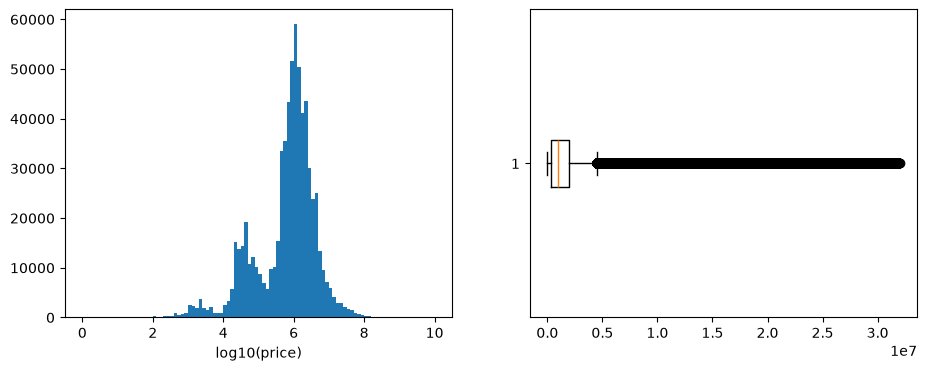

In [164]:
p = cleaned_df["price"].to_pandas()

print(p.quantile([0, .001, .01, .05, .5, .95, .99, .999, 1]))
print("zeros:", (p == 0).sum(), "| under 1000:", (p < 1000).sum())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(np.log10(p[p > 0]), bins=100)
ax[0].set_xlabel("log10(price)")
ax[1].boxplot(p[(p > 1000) & (p < p.quantile(.99))], vert=False)
plt.show()

In [165]:
print(cleaned_df.groupby("estate_benefit")["price"].mean())


estate_benefit
rental    1.213432e+05
sell      4.298270e+06
Name: price, dtype: float64


In [166]:
print(cleaned_df["estate_benefit"].value_counts())

estate_benefit
sell      533399
rental    145991
Name: count, dtype: int64


##### **check the outliers with boxplot**

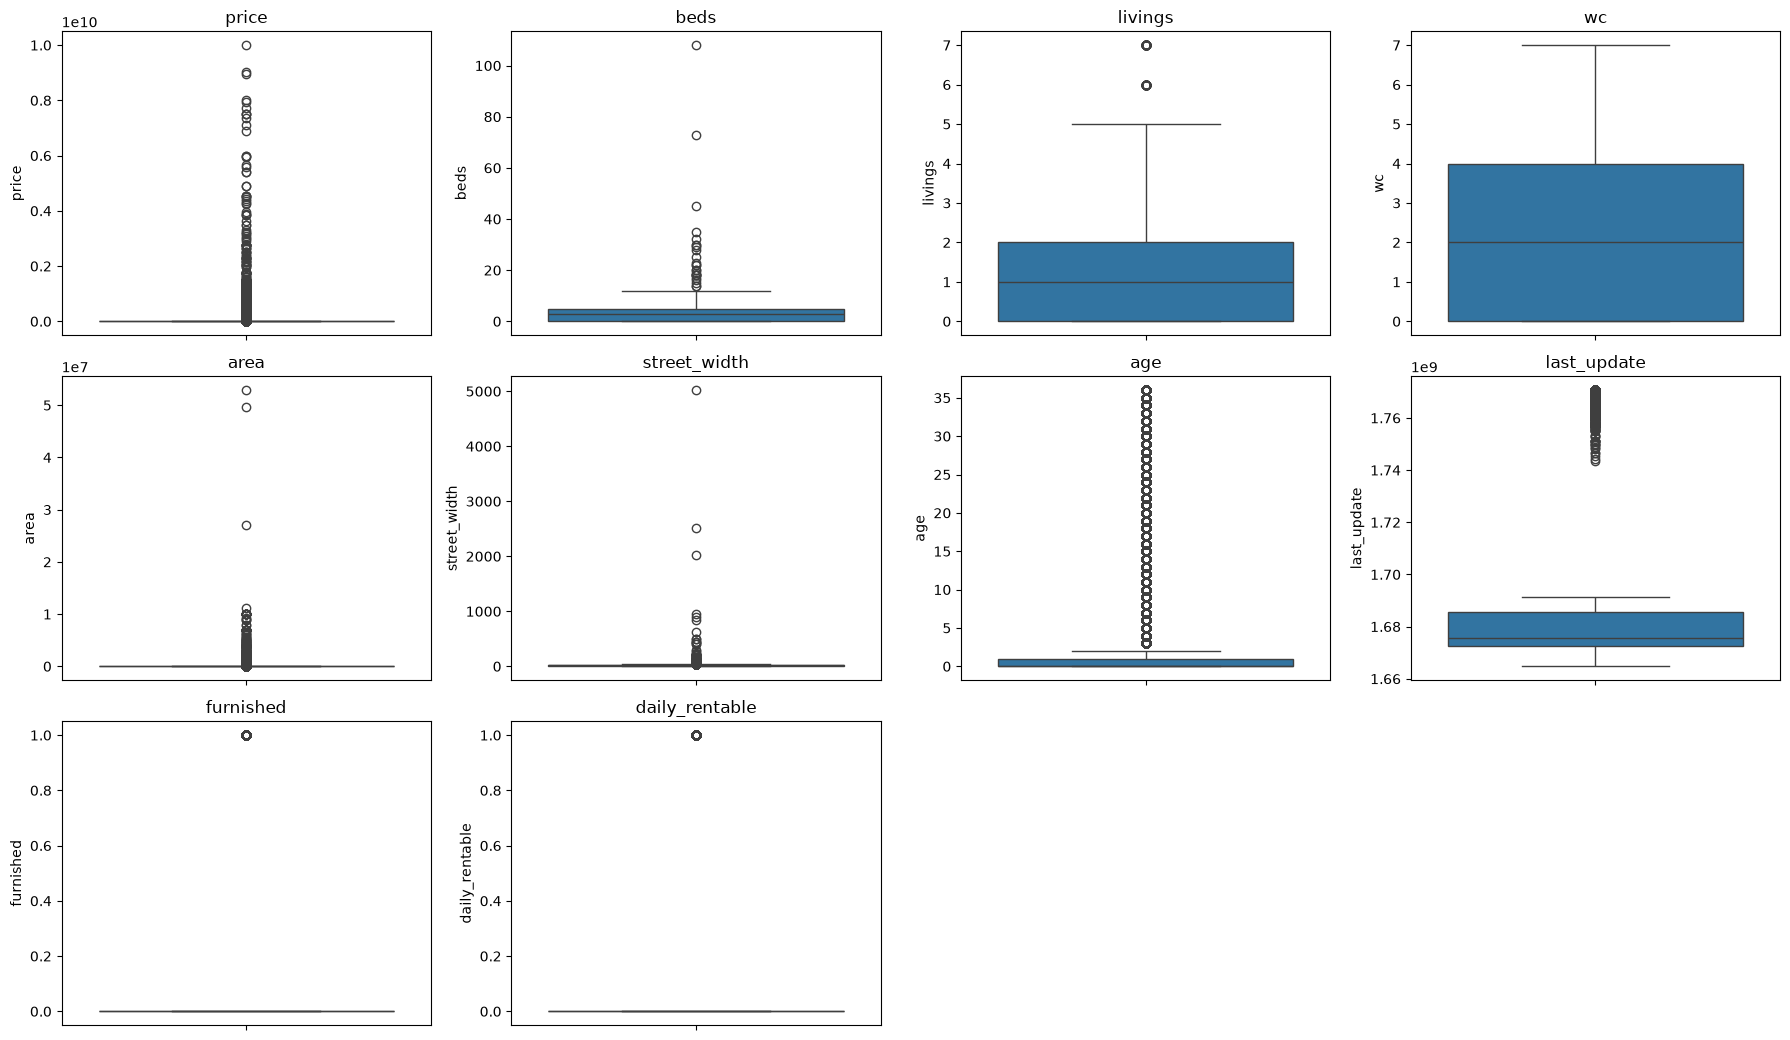

In [ ]:
skip = [c for c in cleaned_df.columns if c.startswith("f_")] + ["id", "city_id", "district_id",'location.lat','location.lng']
num_cols = [c for c in cleaned_df.columns if cleaned_df[c].dtype.kind in "if" and c not in skip]

pdf = cleaned_df[num_cols].to_pandas()

fig, axes = plt.subplots(len(num_cols)//4 + 1, 4, figsize=(18, 3.5*(len(num_cols)//4 + 1)))
for ax, c in zip(axes.flat, num_cols):
    sns.boxplot(y=pdf[c], ax=ax)
    ax.set_title(c)
for ax in axes.flat[len(num_cols):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

In [168]:
cols = ["livings", "wc", "beds", "area", "street_width", "age"]

for c in cols:
    s = cleaned_df[c]
    cut = s.quantile(0.95)
    print(f"\n=== {c} | p95 = {cut} | count above = {(s > cut).sum()} ===")
    print(s[s > cut].value_counts().sort_index().head(20))


=== livings | p95 = 3.0 | count above = 20797 ===
livings
4.0    11206
5.0     9468
6.0       53
7.0       70
Name: count, dtype: int64

=== wc | p95 = 5.0 | count above = 226 ===
wc
6.0    103
7.0    123
Name: count, dtype: int64

=== beds | p95 = 6.0 | count above = 30163 ===
beds
7.0     30116
8.0        15
9.0         1
10.0        2
12.0        4
14.0        2
15.0        1
16.0        1
17.0        1
18.0        4
19.0        1
20.0        2
22.0        2
23.0        1
25.0        1
28.0        1
29.0        1
30.0        2
32.0        1
35.0        1
Name: count, dtype: int64

=== area | p95 = 2040.0 | count above = 33968 ===
area
2041.0     2
2042.0     3
2043.0     7
2044.0     6
2046.0     2
2047.0     1
2048.0     5
2049.0     2
2050.0    51
2051.0     7
2052.0     8
2053.0     2
2054.0     4
2055.0     1
2056.0     1
2057.0     2
2060.0     3
2061.0     6
2062.0     6
2064.0     4
Name: count, dtype: int64

=== street_width | p95 = 40.0 | count above = 31439 ===
street_wid

In [169]:
cols = ["street_width"]

for c in cols:
    s = cleaned_df[c]
    cut = s.quantile(0.99)
    print(f"\n=== {c} | p95 = {cut} | count above = {(s > cut).sum()} ===")
    print(s[s > cut].value_counts().sort_index().head(20))


=== street_width | p95 = 80.0 | count above = 5429 ===
street_width
81.0      105
82.0       43
83.0       36
84.0      218
85.0       53
86.0       18
87.0       17
88.0       24
89.0       17
90.0       80
91.0       27
92.0       30
93.0       23
94.0       16
95.0       50
96.0       37
97.0       28
98.0       33
99.0       48
100.0    4461
Name: count, dtype: int64


##### **الاراضي التي "عرض الشارع" فيها ضخم هذه بالأحرى تكون مخطط او في حي ناشئ**

In [170]:
cleaned_df[cleaned_df["street_width"] >= 500]

,price,beds,livings,wc,area,street_width,age,last_update,furnished,location.lat,location.lng,city,city_id,district,district_id,daily_rentable,estate_type,estate_benefit,f_ac,f_parking,f_furnished,f_new,f_pool,f_kitchen,f_driver,f_basement,f_garden,f_two_entr,f_corner,f_near_masjid,f_investment,f_negotiable,f_urgent,f_near_park,f_yard,beds_na,livings_na,wc_na,age_na,furnished_na,rooms_na,street_width_na
634507,1500000,0.0,0.0,0.0,899.0,899.0,0.0,1768384705,0.0,21.263669,39.244986,جدة,66,حي المسرة,3588,0,land,sell,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,True,True,True,True,True,True,False
650000,5000800,0.0,0.0,0.0,665000.0,950.0,11.0,1770633769,0.0,27.376646,48.441258,النعيرية,45,حي الفيصلية,1510,0,land,sell,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,True,True,True,True,True,True,False
670047,50316,0.0,0.0,0.0,16771.0,5020.0,0.0,1770633826,0.0,24.444655,45.747798,المزاحمية,43,حي الغطغط,886,0,land,rental,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,True,True,True,True,True,True,False
683581,900000,0.0,0.0,0.0,500.0,500.0,0.0,1770634255,0.0,25.032707,46.446652,الرياض,21,حي بنبان,650,0,land,sell,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,True,True,True,True,True,True,False
693095,480110,0.0,0.0,0.0,887.0,2516.0,0.0,1770634292,0.0,21.226191,39.271843,جدة,66,حي البركة,3442,0,land,sell,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,True,True,True,True,True,True,False
727640,3000000,0.0,0.0,0.0,235725.0,630.0,11.0,1770633629,0.0,27.710812,47.288293,النعيرية,45,حي الفيصلية,1510,0,farm,sell,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,True,True,True,False,True,True,False
737095,170000,0.0,0.0,0.0,200.0,850.0,0.0,1770634297,0.0,24.442182,46.796451,الرياض,21,حي عريض,696,0,land,sell,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,True,True,True,True,True,True,False
757072,290000000,0.0,0.0,0.0,100000.0,500.0,0.0,1770634558,0.0,24.971203,46.593053,الرياض,21,حي النرجس,600,0,land,sell,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,True,True,True,True,True,True,False
761521,436212,0.0,0.0,0.0,323.0,2015.0,0.0,1770634380,0.0,25.105282,46.388785,الرياض,21,حي بنبان,650,0,land,sell,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,True,True,True,True,True,True,False


##### **Distributions for features**

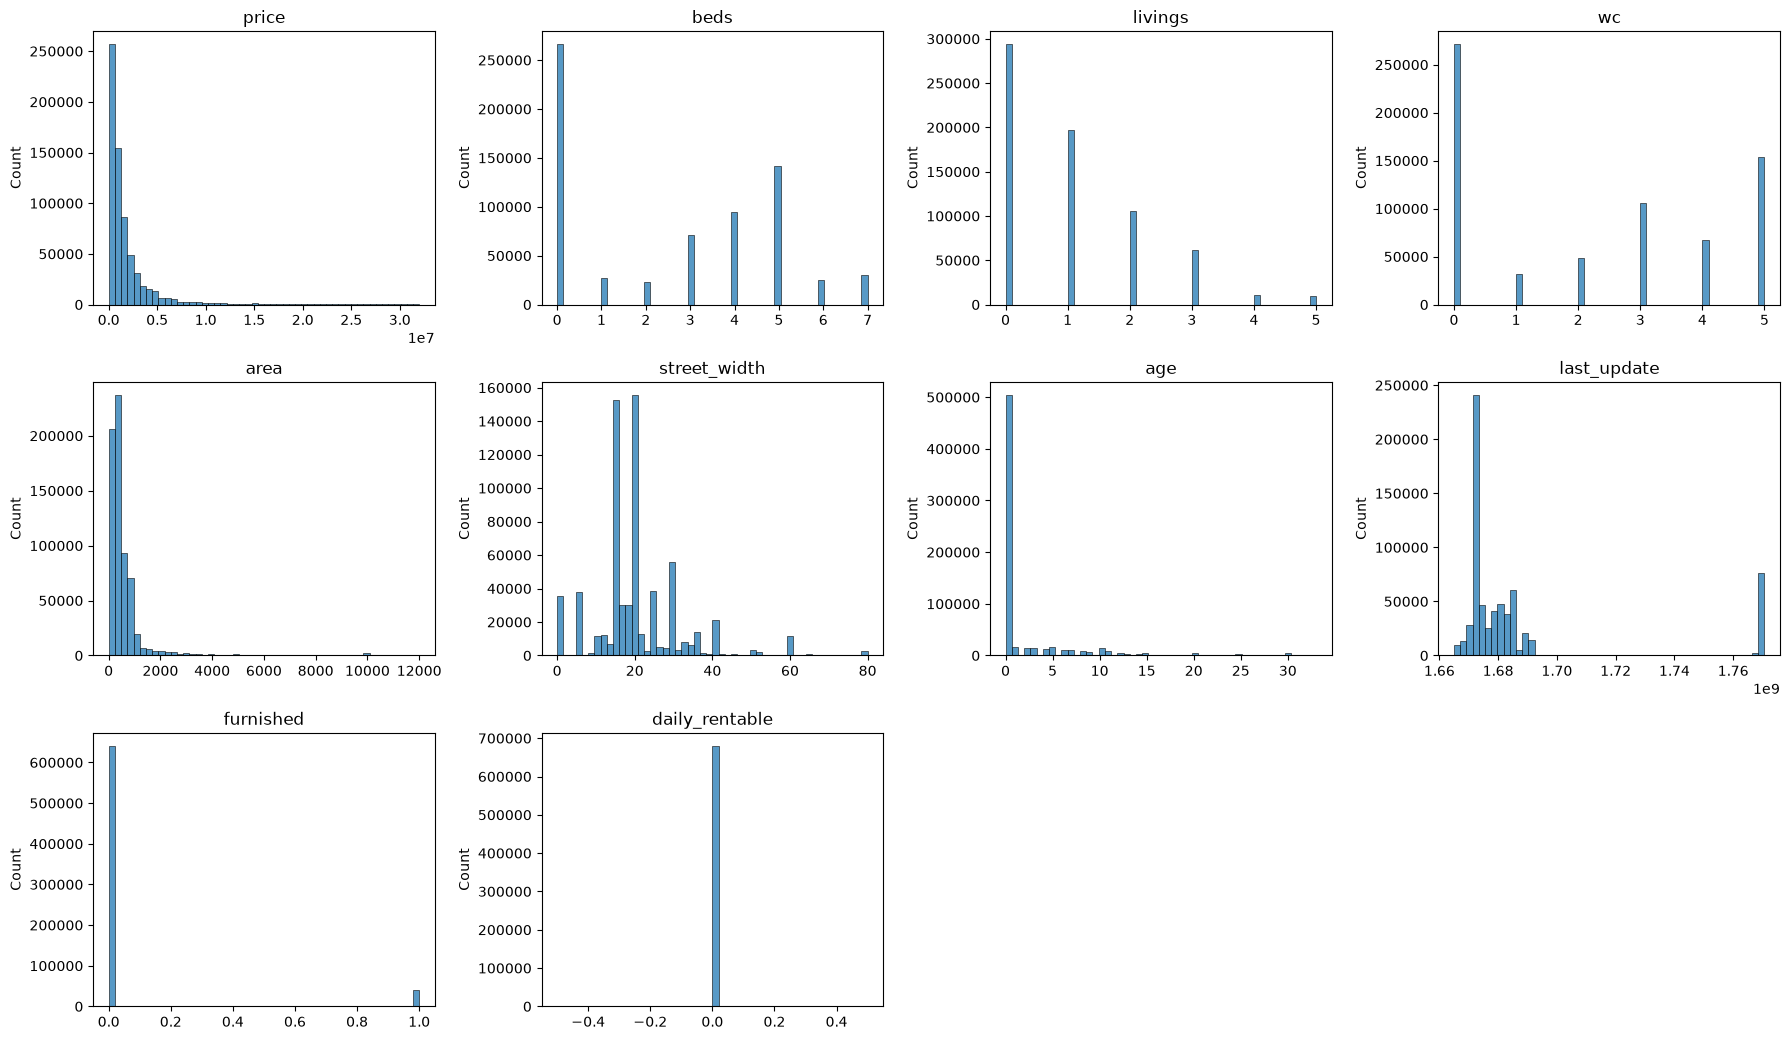

In [171]:
skip = [c for c in cleaned_df.columns if c.startswith("f_")] + ["id", "city_id", "district_id",'location.lat','location.lng']
num_cols = [c for c in cleaned_df.columns
            if cleaned_df[c].dtype.kind in "if" and c not in skip]

pdf = cleaned_df[num_cols].to_pandas()

n = len(num_cols); ncol = 4; nrow = -(-n // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(18, 3.5*nrow))

for ax, c in zip(axes.flat, num_cols):
    s = pdf[c].dropna()
    s = s[(s >= s.quantile(.001)) & (s <= s.quantile(.99))]   # trim tails so shape is visible
    sns.histplot(s, bins=50, ax=ax)
    ax.set_title(c); ax.set_xlabel("")

for ax in axes.flat[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()

In [172]:
cleaned_df['daily_rentable'].value_counts()

daily_rentable
0    679227
1       163
Name: count, dtype: int64

In [173]:
cleaned_df.drop(columns=['rooms_na'],inplace=True)

#### **Things I will do**
##### 1. Normalize column names and datatypes and places of features
##### 2. Convert `_na` boolean columns to int
##### 3. drop age feature , because its overwhelm the models in future
##### 4. Split into two datasets: rental and sell
##### 5. Encoding (categorical columns)
##### 6. Transform + standardize — fit on train only

In [174]:
cleaned_df.columns

Index(['price', 'beds', 'livings', 'wc', 'area', 'street_width', 'age', 'last_update', 'furnished', 'location.lat', 'location.lng', 'city', 'city_id', 'district', 'district_id', 'daily_rentable', 'estate_type', 'estate_benefit', 'f_ac', 'f_parking', 'f_furnished', 'f_new', 'f_pool', 'f_kitchen', 'f_driver', 'f_basement', 'f_garden', 'f_two_entr', 'f_corner', 'f_near_masjid', 'f_investment', 'f_negotiable', 'f_urgent', 'f_near_park', 'f_yard', 'beds_na', 'livings_na', 'wc_na', 'age_na', 'furnished_na', 'street_width_na'], dtype='str')

In [175]:
cleaned_df.groupby(["furnished","f_furnished"]).size()

furnished  f_furnished
0.0        0              637103
1.0        1                6074
           0               33232
0.0        1                2981
dtype: int64

In [176]:
cleaned_df["furnished"] = ((cleaned_df["furnished"] == 1) | (cleaned_df["f_furnished"] == 1)).astype("int8")
cleaned_df = cleaned_df.drop(columns=["f_furnished"])

In [177]:
cleaned_df["furnished"].value_counts()

furnished
0    637103
1     42287
Name: count, dtype: int64

In [178]:
area = cleaned_df["area"]
cleaned_df["price_per_m2"] = (cleaned_df["price"] / area.where(area > 0)).round(2)

In [179]:
cleaned_df["price_per_m2"].describe()

count    6.793790e+05
mean     3.953346e+03
std      4.292565e+04
min      0.000000e+00
25%      6.333300e+02
50%      3.100000e+03
75%      5.000000e+03
max      2.500000e+07
Name: price_per_m2, dtype: float64

In [180]:
rename_map = {
    "wc":               "bathrooms",
    "livings":          "living_rooms",
    "beds":             "bedrooms",
    "area":             "area_m2",
    "age":              "age_years",
    "street_width":     "street_width_m",
    "furnished":        "is_furnished",
    "daily_rentable":   "is_daily_rentable",
    "f_ac":             "has_ac",
    "f_parking":        "has_parking",
    "f_new":            "is_new",
    "f_pool":           "has_pool",
    "f_kitchen":        "has_kitchen",
    "f_driver":         "has_driver_room",
    "f_basement":       "has_basement",
    "f_garden":         "has_garden",
    "f_two_entr":       "has_two_entrances",
    "f_corner":         "is_corner",
    "f_near_masjid":    "near_masjid",
    "f_investment":     "is_investment",
    "f_negotiable":     "is_negotiable",
    "f_urgent":         "is_urgent",
    "f_near_park":      "near_park",
    "f_yard":           "has_yard",

    "beds_na":          "bedrooms_missing",
    "livings_na":       "living_rooms_missing",
    "wc_na":            "bathrooms_missing",
    "age_na":           "age_missing",
    "furnished_na":     "furnished_missing",
    "street_width_na":  "street_width_missing",
}

cleaned_df = cleaned_df.rename(columns=rename_map)

In [181]:
cleaned_df.sample()

,price,bedrooms,living_rooms,bathrooms,area_m2,street_width_m,age_years,last_update,is_furnished,location.lat,location.lng,city,city_id,district,district_id,is_daily_rentable,estate_type,estate_benefit,has_ac,has_parking,is_new,has_pool,has_kitchen,has_driver_room,has_basement,has_garden,has_two_entrances,is_corner,near_masjid,is_investment,is_negotiable,is_urgent,near_park,has_yard,bedrooms_missing,living_rooms_missing,bathrooms_missing,age_missing,furnished_missing,street_width_missing,price_per_m2
519380,650000,5.0,1.0,3.0,171.0,20.0,0.0,1677752048,0,21.616788,39.148065,جدة,66,حي النعيم,3606,0,apartment,sell,1,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,False,False,False,False,False,True,3801.17


##### 2. Convert `_na` boolean columns to int

In [182]:
for c in [c for c in cleaned_df.columns if c.endswith("_missing")]:
    cleaned_df[c] = cleaned_df[c].astype("int8")

In [183]:
for c in [c for c in cleaned_df.columns if c.endswith("_missing")]:
    print(cleaned_df[c].unique())

0    0
1    1
Name: bedrooms_missing, dtype: int8
0    0
1    1
Name: living_rooms_missing, dtype: int8
0    0
1    1
Name: bathrooms_missing, dtype: int8
0    0
1    1
Name: age_missing, dtype: int8
0    0
1    1
Name: furnished_missing, dtype: int8
0    1
1    0
Name: street_width_missing, dtype: int8


##### 3. drop age feature , because its overwhelm the models in future

In [184]:
cleaned_df = cleaned_df.drop(columns=["age_years", "age_missing"])

##### drop is_daily_rentable, because only 163 rows out of 677K (0.024%) equal 1 , means rentable

In [185]:
cleaned_df = cleaned_df.drop(columns=["is_daily_rentable"])

##### 4. Split into two datasets: rental and sell

Sale and rental prices are different quantities on different scales; one model over
both would spend its capacity learning which is which. Coordinates and ids leave here
too — they belong to the analysis notebook, not to a price model.

In [187]:
DROP = ["price_per_m2",  'district_id', "estate_benefit" , 'city_id' , 'location.lng' , 'location.lat']

sell = cleaned_df[cleaned_df["estate_benefit"] == "sell"].drop(columns=DROP).reset_index(drop=True)
rent = cleaned_df[cleaned_df["estate_benefit"] == "rental"].drop(columns=DROP).reset_index(drop=True)

sell.to_parquet("../data/model_sell_estates.parquet", index=False)
rent.to_parquet("../data/model_rental_estates.parquet", index=False)

print(sell.shape, rent.shape)

(533399, 32) (145991, 32)


In [189]:
print(cleaned_df.columns.tolist())

['price', 'bedrooms', 'living_rooms', 'bathrooms', 'area_m2', 'street_width_m', 'last_update', 'is_furnished', 'location.lat', 'location.lng', 'city', 'city_id', 'district', 'district_id', 'estate_type', 'estate_benefit', 'has_ac', 'has_parking', 'is_new', 'has_pool', 'has_kitchen', 'has_driver_room', 'has_basement', 'has_garden', 'has_two_entrances', 'is_corner', 'near_masjid', 'is_investment', 'is_negotiable', 'is_urgent', 'near_park', 'has_yard', 'bedrooms_missing', 'living_rooms_missing', 'bathrooms_missing', 'furnished_missing', 'street_width_missing', 'price_per_m2']


##### **Transform Data**

In [190]:
%%time
rental_data = cudf.read_parquet('../data/model_rental_estates.parquet')
sell_data   = cudf.read_parquet('../data/model_sell_estates.parquet')

df_rent = rental_data.copy()
df_sell = sell_data.copy()

CPU times: user 18.7 ms, sys: 37.6 ms, total: 56.4 ms
Wall time: 64.7 ms


In [191]:
df_rent.sample()

,price,bedrooms,living_rooms,bathrooms,area_m2,street_width_m,last_update,is_furnished,city,district,estate_type,has_ac,has_parking,is_new,has_pool,has_kitchen,has_driver_room,has_basement,has_garden,has_two_entrances,is_corner,near_masjid,is_investment,is_negotiable,is_urgent,near_park,has_yard,bedrooms_missing,living_rooms_missing,bathrooms_missing,furnished_missing,street_width_missing
33035,35000,3.0,1.0,2.0,170.0,36.0,1672743657,0,الرياض,حي الحمراء,apartment,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [193]:
df_rent.drop(columns=['last_update'],inplace=True)

In [199]:
df_rent.drop(columns=['is_new'],inplace=True)

In [200]:
df_rent.shape

(145991, 30)

In [204]:
df_rent.sample()

,price,bedrooms,living_rooms,bathrooms,area_m2,street_width_m,is_furnished,city,district,estate_type,has_ac,has_parking,has_pool,has_kitchen,has_driver_room,has_basement,has_garden,has_two_entrances,is_corner,near_masjid,is_investment,is_negotiable,is_urgent,near_park,has_yard,bedrooms_missing,living_rooms_missing,bathrooms_missing,furnished_missing,street_width_missing
132649,42000,2.0,1.0,1.0,70.0,0.0,0,الرياض,حي الوزارات,apartment,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [196]:
df_sell.drop(columns=['last_update'],inplace=True)

In [202]:
df_sell.drop(columns=['is_new'],inplace=True)

In [203]:
df_sell.shape

(533399, 30)

In [205]:
df_sell.sample()

,price,bedrooms,living_rooms,bathrooms,area_m2,street_width_m,is_furnished,city,district,estate_type,has_ac,has_parking,has_pool,has_kitchen,has_driver_room,has_basement,has_garden,has_two_entrances,is_corner,near_masjid,is_investment,is_negotiable,is_urgent,near_park,has_yard,bedrooms_missing,living_rooms_missing,bathrooms_missing,furnished_missing,street_width_missing
428998,600000,3.0,1.0,3.0,126.0,30.0,0,الرياض,حي الجنادرية,apartment,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [206]:
# encoding for both datasets
df_rent = cudf.get_dummies(df_rent, columns=["estate_type"], prefix="type", drop_first=False)
df_sell = cudf.get_dummies(df_sell,columns=["estate_type"], prefix="type", drop_first=False)

In [207]:
df_sell.sample()

,price,bedrooms,living_rooms,bathrooms,area_m2,street_width_m,is_furnished,city,district,has_ac,has_parking,has_pool,has_kitchen,has_driver_room,has_basement,has_garden,has_two_entrances,is_corner,near_masjid,is_investment,is_negotiable,is_urgent,near_park,has_yard,bedrooms_missing,living_rooms_missing,bathrooms_missing,furnished_missing,street_width_missing,type_apartment,type_building,type_esterahah,type_farm,type_floor,type_house,type_land,type_store,type_villa
336206,950000,6.0,3.0,5.0,279.0,32.0,0,الدمام,حي ضاحية الملك فهد,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,False,False,True


In [208]:
for c in [c for c in df_rent.columns if c.startswith("type")]:
    df_rent[c] = df_rent[c].astype("int8")

In [210]:
df_rent.sample()

,price,bedrooms,living_rooms,bathrooms,area_m2,street_width_m,is_furnished,city,district,has_ac,has_parking,has_pool,has_kitchen,has_driver_room,has_basement,has_garden,has_two_entrances,is_corner,near_masjid,is_investment,is_negotiable,is_urgent,near_park,has_yard,bedrooms_missing,living_rooms_missing,bathrooms_missing,furnished_missing,street_width_missing,type_apartment,type_building,type_campsite,type_chalet,type_esterahah,type_floor,type_furnished_apartment,type_house,type_land,type_office,type_room,type_store,type_villa,type_warehouse
56038,30000,3.0,1.0,2.0,130.0,15.0,0,الرياض,حي اليرموك,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [211]:
for c in [c for c in df_sell.columns if c.startswith("type")]:
    df_sell[c] = df_sell[c].astype("int8")

In [212]:
df_sell.sample()

,price,bedrooms,living_rooms,bathrooms,area_m2,street_width_m,is_furnished,city,district,has_ac,has_parking,has_pool,has_kitchen,has_driver_room,has_basement,has_garden,has_two_entrances,is_corner,near_masjid,is_investment,is_negotiable,is_urgent,near_park,has_yard,bedrooms_missing,living_rooms_missing,bathrooms_missing,furnished_missing,street_width_missing,type_apartment,type_building,type_esterahah,type_farm,type_floor,type_house,type_land,type_store,type_villa
420378,450000,0.0,0.0,0.0,500.0,30.0,0,حائل,حي العزيزية,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,1,1,0,0,0,0,0,0,0,1,0,0


In [ ]:
'''df_sell.to_parquet("../data/SELL_REAL_ESTATE_FOR_MODELING.parquet")
df_rent.to_parquet("../data/RENT_REAL_ESTATE_FOR_MODELING.parquet")
'''